In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
long_con,short_con,middle_con = create_df_by_type(con_df)

In [4]:
long_nostart.head_angle_velocity

8        [-0.7889109863396171, -1.2130015355926194, -1....
12       [0.7696098153513042, 1.0033757497222928, 0.646...
17       [-0.16380271173372485, -0.24914577199065757, -...
22       [0.9471240128070324, 1.2215840953852908, 0.852...
24       [-0.20729661037794278, -0.3713595448874485, -0...
                               ...                        
14500    [-1.4794197064388204, -2.7033760087380476, -3....
14515    [-2.118775955169289, -3.8692407724827484, -4.9...
14523    [1.6347577660386703, 2.8529514558113167, 3.478...
14535    [-2.808722157630832, -4.443885350271759, -4.52...
14547    [-1.6729257610084347, -3.1096259025966355, -4....
Name: head_angle_velocity, Length: 5295, dtype: object

In [18]:
from scipy.signal import find_peaks

In [ ]:
ax[2].plot(peaks, np.abs(row.head_angle_velocity)[peaks], "x")
ax[1].scatter(peaks[0], row.head_angle_velocity[peaks[0]], marker = "x")

In [20]:
peaks

array([17, 28, 46, 56], dtype=int64)

In [38]:
_['peak_heights']

array([4.73242493, 4.2373052 , 4.32237454, 3.78130824])

In [37]:
_['peak_heights'].argmax()

0

In [41]:
peaks

array([ 3, 26, 37, 47], dtype=int64)

In [64]:
def angle_to_corner_before_after_turn(df):
    for ind,row in df.iterrows():
        turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
        df.at[ind,'angle_to_corner_before'] = np.mean(row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:])
        df.at[ind,'angle_to_corner_after'] = np.nanmean(row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:])
        df.at[ind,'speed_before'] = np.nanmean(row.ts_speed[:int(row.obstacle_ind)][:turn_index][-10:])
        df.at[ind,'speed_after'] = np.nanmean(row.ts_speed[:int(row.obstacle_ind)][turn_index:][-10:])


In [ ]:
data =long_nostart[long_nostart.turn_to_obstacle == 'towards'].sample(15)
for ind,row in data.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = data.loc[[ind]]
    plot_arena(data,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title('angular velocity head')
    ax[2].set_title('head angle')
   
    #ax[1].set_ylim(-12,2)
    ax[1].set_xlabel('distance to obstacle')
    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]),color = 'tab:orange')
    #thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]),color = 'tab:orange')
    ax[1].plot(peaks[max_peak], np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[peaks[max_peak]], "x")
    ax[2].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)][peaks[max_peak]], np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[peaks[max_peak]], "x")
    ax[0].plot(row.ts_nose_x_cm[:int(row.obstacle_ind)][peaks[max_peak]], np.abs(row.ts_nose_y_cm[:int(row.obstacle_ind)])[peaks[max_peak]], "x",color = 'black')

In [74]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index]

32.04339545074362

In [87]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index]

array([83.88841773823596, 82.2483303440686, 70.05795423735829,
       70.14169644192945, 60.61415272487691, 64.81597056570104,
       58.8986055816817, 54.76127493960897, 56.51821499346792,
       51.87901839169441, 52.47962679475468, 49.723362768452354,
       48.95161818479657, 51.480146868460345, 51.88176473123607,
       55.62964431835727, 55.39395788362198, 53.41640611992646,
       50.932185717196354, 50.97898056410655, 51.63640625128646,
       55.9588636171896, 52.86576476939958, 53.57702950833468,
       60.62672706867757, 60.26106646733985, 62.33936559034098,
       62.885331706859304, 61.835981460410856, 58.797925281822444,
       58.82890124586265, 58.94788422255953, 57.739747190702104,
       60.52978437799283, 61.34682949175202, 61.3484343989863,
       58.07205686043562, 53.91603248583229, 51.12597296086422,
       51.065004571885964, 50.51558191426199, 41.32460941237663,
       40.20683313002137, 37.53357443157361], dtype=object)

In [88]:
row.ts_angle_to_corner[:int(row.obstacle_ind)]

array([83.88841773823596, 82.2483303440686, 70.05795423735829,
       70.14169644192945, 60.61415272487691, 64.81597056570104,
       58.8986055816817, 54.76127493960897, 56.51821499346792,
       51.87901839169441, 52.47962679475468, 49.723362768452354,
       48.95161818479657, 51.480146868460345, 51.88176473123607,
       55.62964431835727, 55.39395788362198, 53.41640611992646,
       50.932185717196354, 50.97898056410655, 51.63640625128646,
       55.9588636171896, 52.86576476939958, 53.57702950833468,
       60.62672706867757, 60.26106646733985, 62.33936559034098,
       62.885331706859304, 61.835981460410856, 58.797925281822444,
       58.82890124586265, 58.94788422255953, 57.739747190702104,
       60.52978437799283, 61.34682949175202, 61.3484343989863,
       58.07205686043562, 53.91603248583229, 51.12597296086422,
       51.065004571885964, 50.51558191426199, 41.32460941237663,
       40.20683313002137, 37.53357443157361, 32.04339545074362,
       26.30275283837049, 25.4156967

In [93]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index]

array([83.88841773823596, 82.2483303440686, 70.05795423735829,
       70.14169644192945, 60.61415272487691, 64.81597056570104,
       58.8986055816817, 54.76127493960897, 56.51821499346792,
       51.87901839169441, 52.47962679475468, 49.723362768452354,
       48.95161818479657, 51.480146868460345, 51.88176473123607,
       55.62964431835727, 55.39395788362198, 53.41640611992646,
       50.932185717196354, 50.97898056410655, 51.63640625128646,
       55.9588636171896, 52.86576476939958, 53.57702950833468,
       60.62672706867757, 60.26106646733985, 62.33936559034098,
       62.885331706859304, 61.835981460410856, 58.797925281822444,
       58.82890124586265, 58.94788422255953, 57.739747190702104,
       60.52978437799283, 61.34682949175202, 61.3484343989863,
       58.07205686043562, 53.91603248583229, 51.12597296086422,
       51.065004571885964, 50.51558191426199, 41.32460941237663,
       40.20683313002137, 37.53357443157361], dtype=object)

In [100]:
np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index],row.ts_angle_to_corner[:int(row.obstacle_ind)])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [97]:
 np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)], row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index]))


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43], dtype=int64),)

In [94]:
np.where(row.ts_angle_to_corner[:int(row.obstacle_ind)]==row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index])

(array([], dtype=int64),)

In [92]:
row.ts_angle_to_corner[:int(row.obstacle_ind)]

array([83.88841773823596, 82.2483303440686, 70.05795423735829,
       70.14169644192945, 60.61415272487691, 64.81597056570104,
       58.8986055816817, 54.76127493960897, 56.51821499346792,
       51.87901839169441, 52.47962679475468, 49.723362768452354,
       48.95161818479657, 51.480146868460345, 51.88176473123607,
       55.62964431835727, 55.39395788362198, 53.41640611992646,
       50.932185717196354, 50.97898056410655, 51.63640625128646,
       55.9588636171896, 52.86576476939958, 53.57702950833468,
       60.62672706867757, 60.26106646733985, 62.33936559034098,
       62.885331706859304, 61.835981460410856, 58.797925281822444,
       58.82890124586265, 58.94788422255953, 57.739747190702104,
       60.52978437799283, 61.34682949175202, 61.3484343989863,
       58.07205686043562, 53.91603248583229, 51.12597296086422,
       51.065004571885964, 50.51558191426199, 41.32460941237663,
       40.20683313002137, 37.53357443157361, 32.04339545074362,
       26.30275283837049, 25.4156967

In [82]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index]

array([83.88841773823596, 82.2483303440686, 70.05795423735829,
       70.14169644192945, 60.61415272487691, 64.81597056570104,
       58.8986055816817, 54.76127493960897, 56.51821499346792,
       51.87901839169441, 52.47962679475468, 49.723362768452354,
       48.95161818479657, 51.480146868460345, 51.88176473123607,
       55.62964431835727, 55.39395788362198, 53.41640611992646,
       50.932185717196354, 50.97898056410655, 51.63640625128646,
       55.9588636171896, 52.86576476939958, 53.57702950833468,
       60.62672706867757, 60.26106646733985, 62.33936559034098,
       62.885331706859304, 61.835981460410856, 58.797925281822444,
       58.82890124586265, 58.94788422255953, 57.739747190702104,
       60.52978437799283, 61.34682949175202, 61.3484343989863,
       58.07205686043562, 53.91603248583229, 51.12597296086422,
       51.065004571885964, 50.51558191426199, 41.32460941237663,
       40.20683313002137, 37.53357443157361], dtype=object)

In [81]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:]

array([61.34682949175202, 61.3484343989863, 58.07205686043562,
       53.91603248583229, 51.12597296086422, 51.065004571885964,
       50.51558191426199, 41.32460941237663, 40.20683313002137,
       37.53357443157361], dtype=object)

In [108]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:]

array([6.7164681578400325, 0.6898867189846475, 0.6810127688670892,
       2.1263450020336587, 0.7774799928628712, 0.5194746783379033,
       12.600634124400637, 8.934563323550163, 8.809096564513018,
       9.735780025508332], dtype=object)

In [150]:
after_x

array([38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55], dtype=int64)

In [151]:
row.ts_zero_out_angle_to_corner[:int(row.obstacle_ind)][turn_index:][:10]

array([57.129335748998564, 46.737479602185275, 33.26590887858228,
       25.76586487153017, 15.723928782304387, 12.135220262851806,
       4.4776982745660305, 2.8596197462953237, 0, 0], dtype=object)

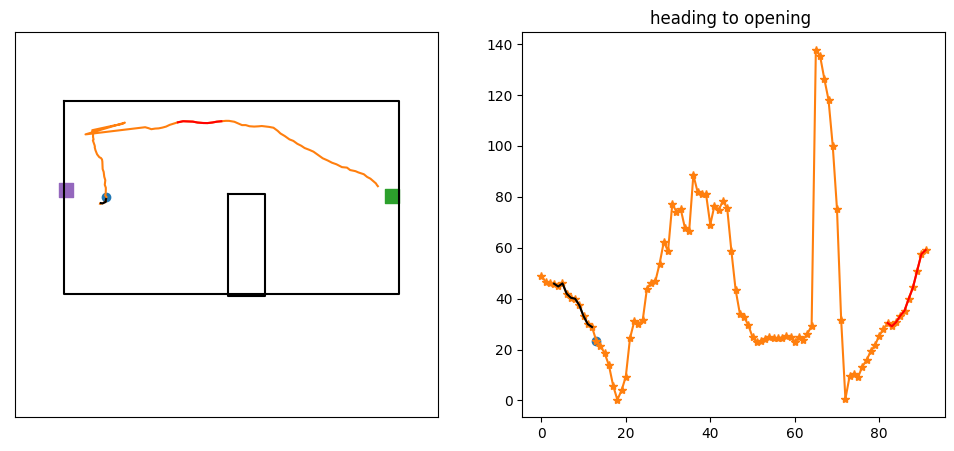

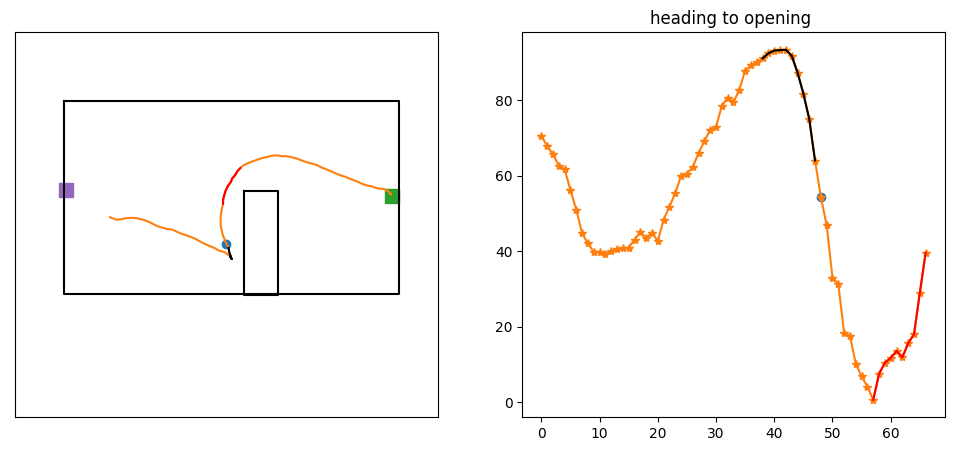

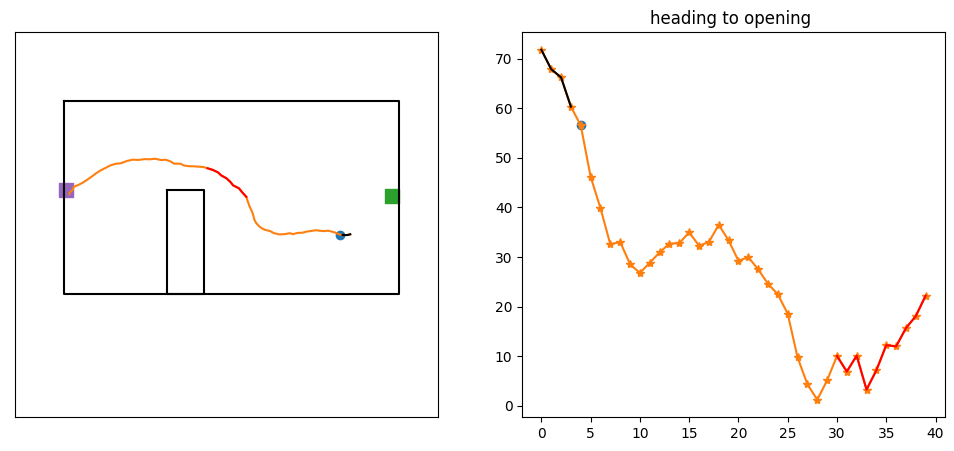

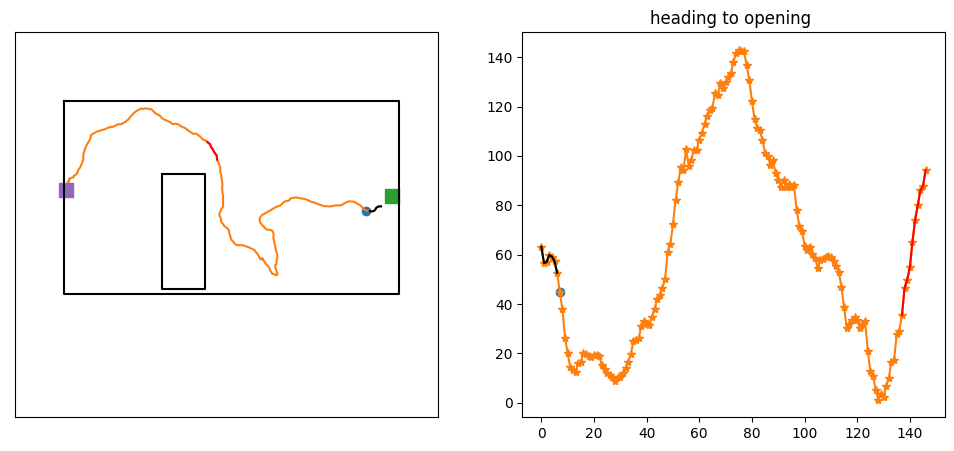

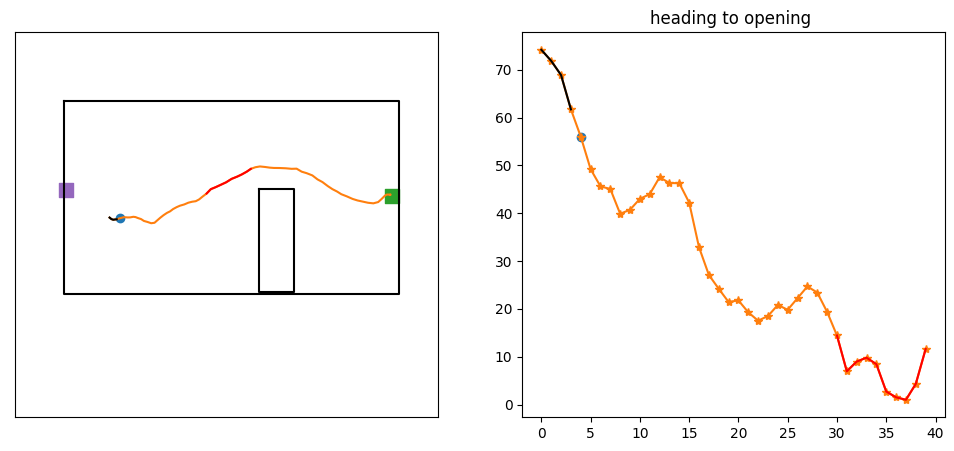

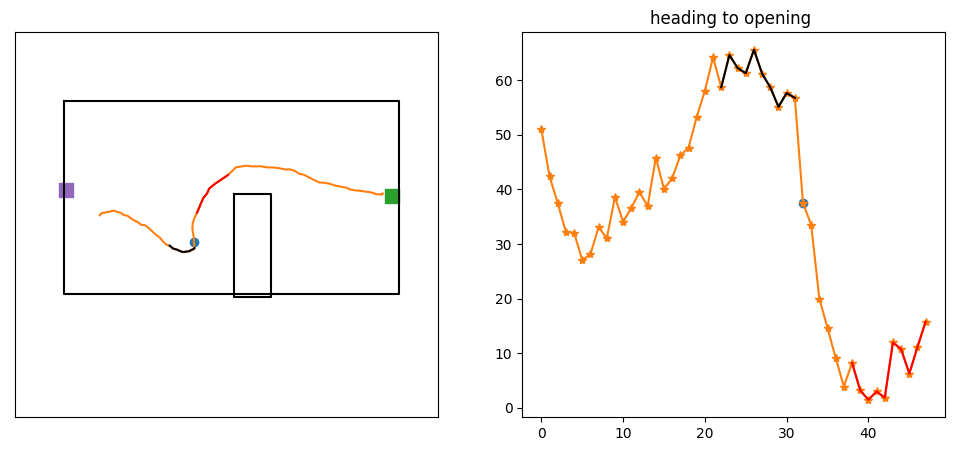

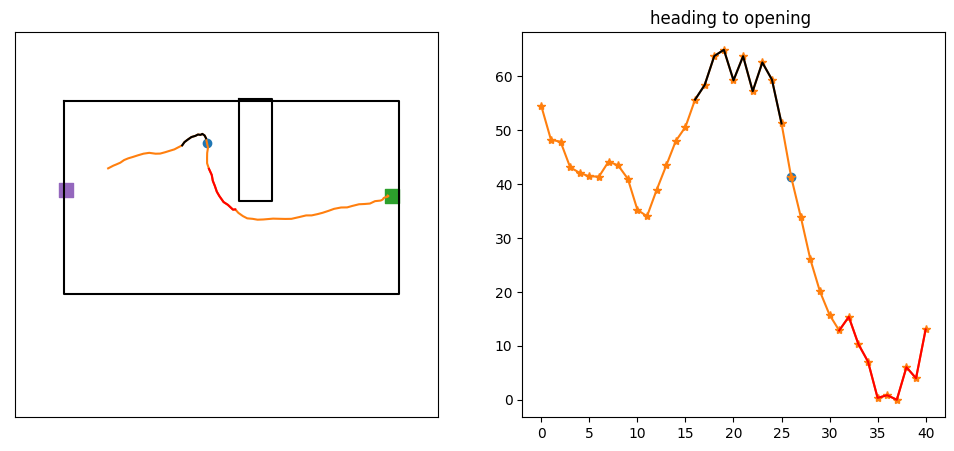

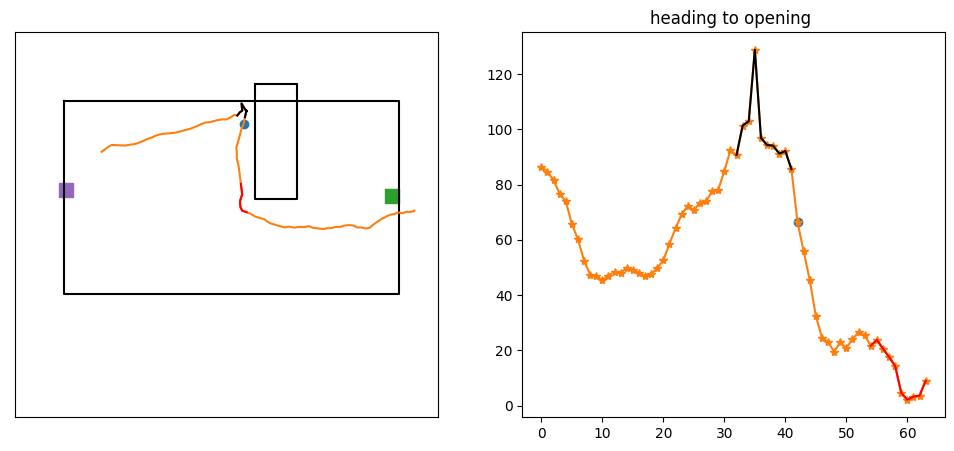

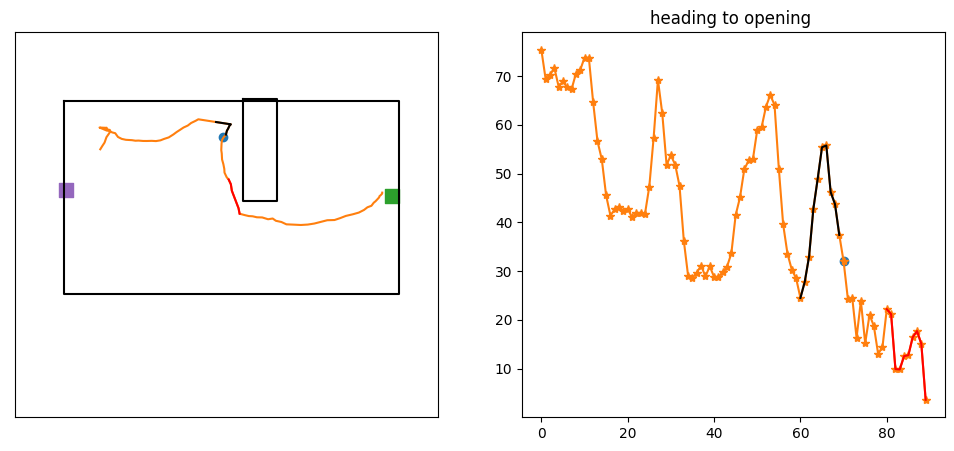

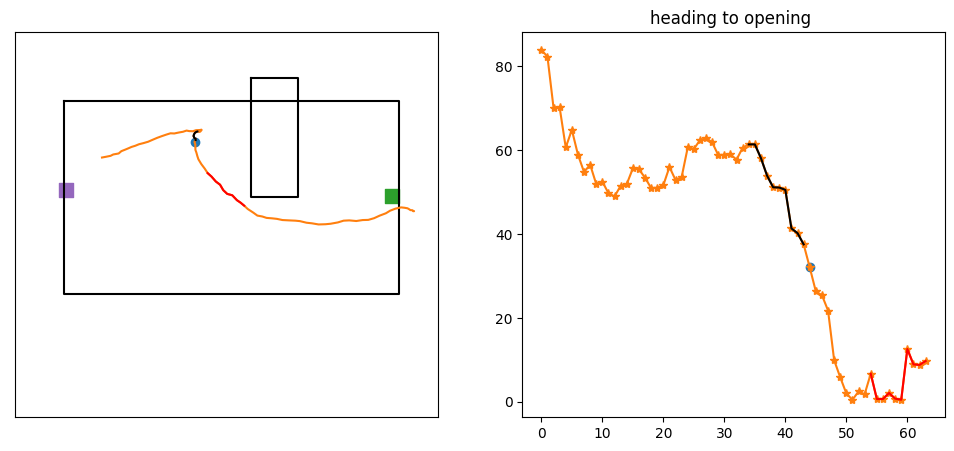

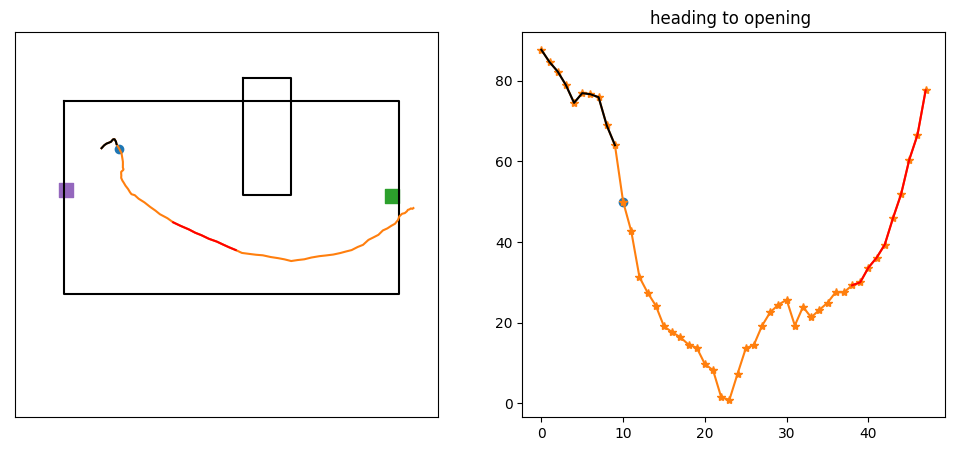

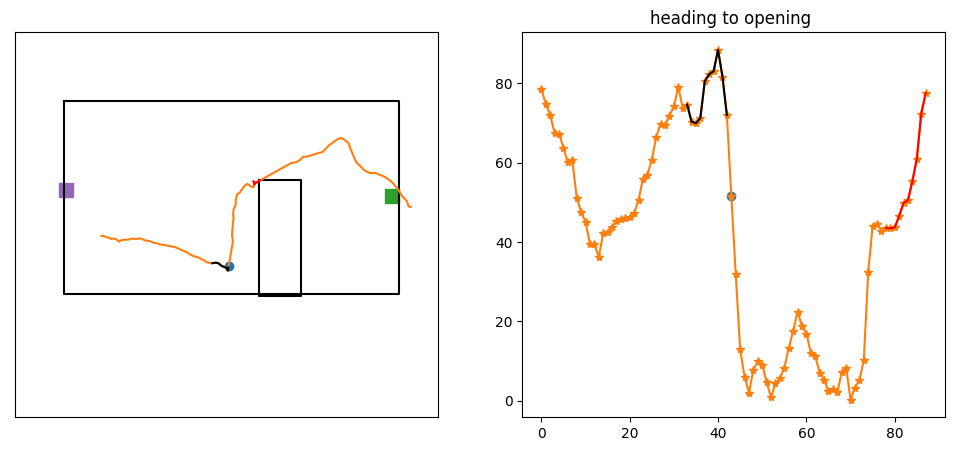

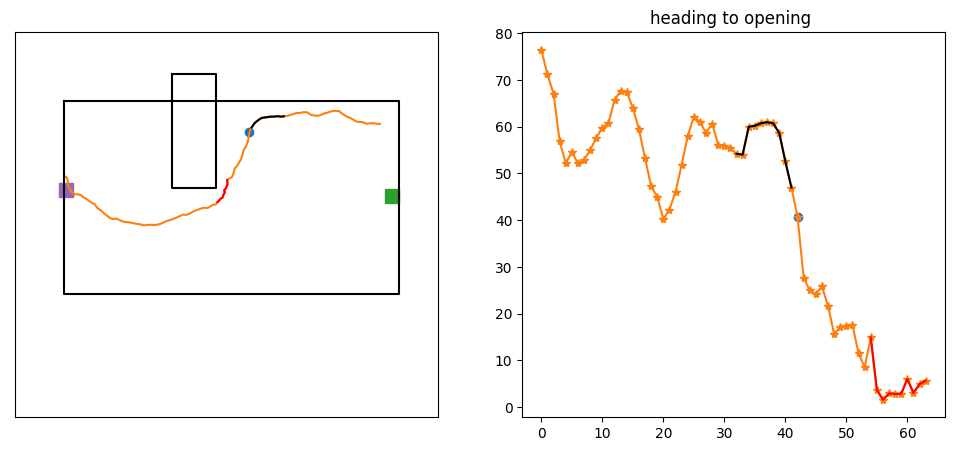

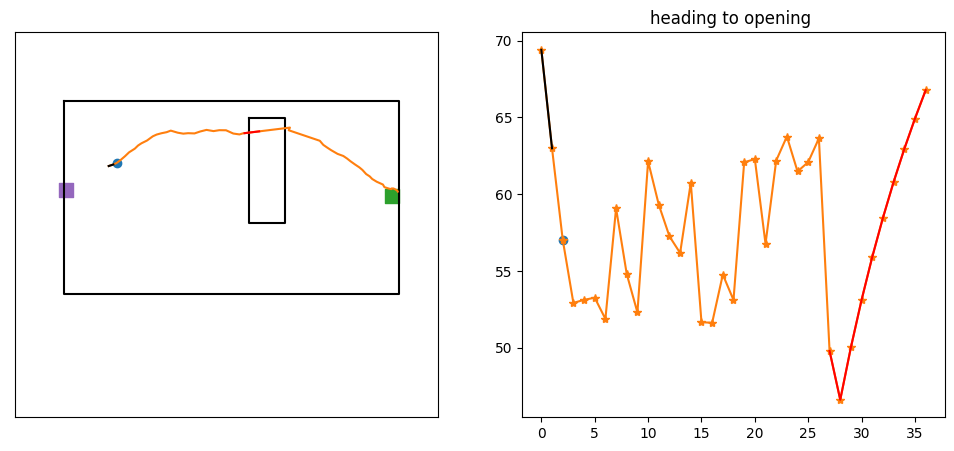

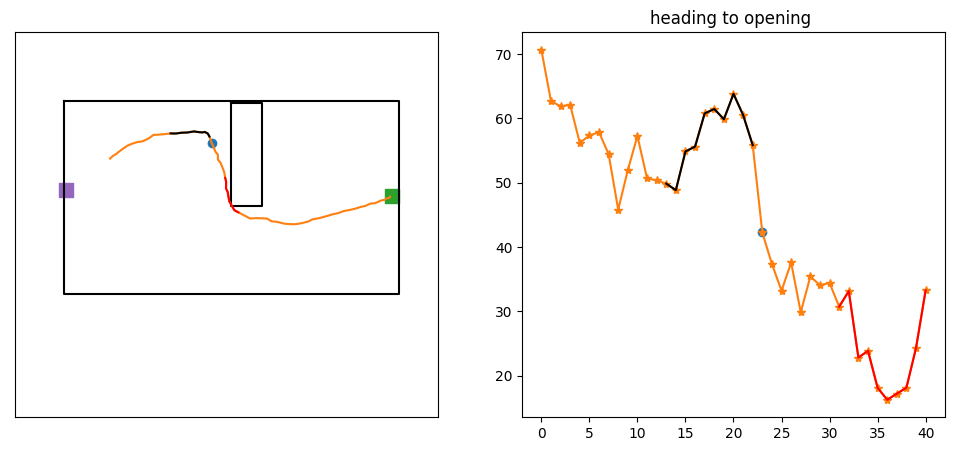

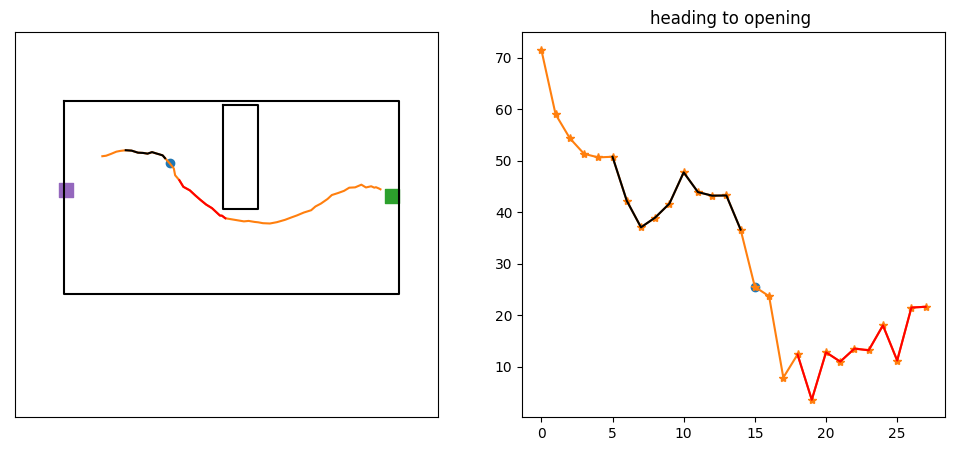

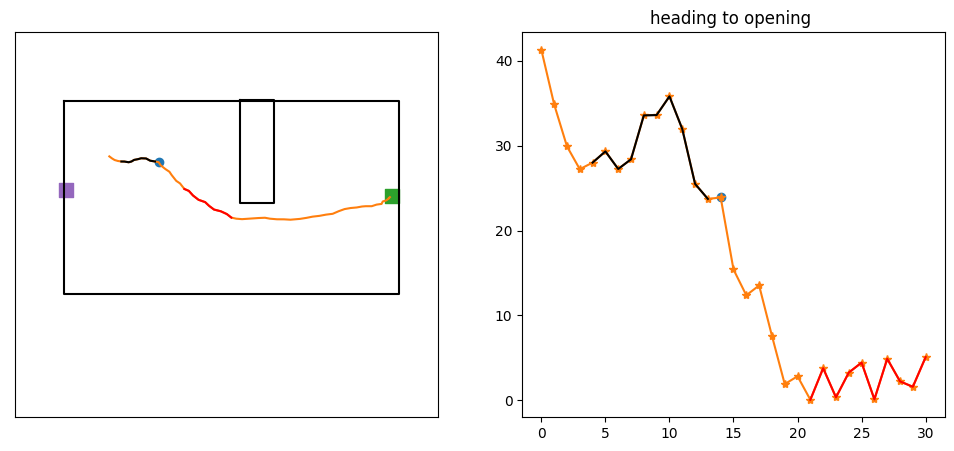

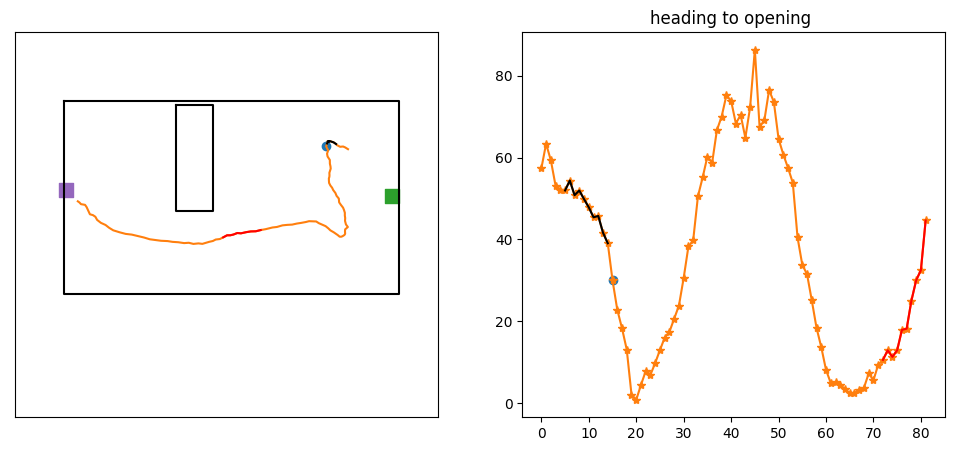

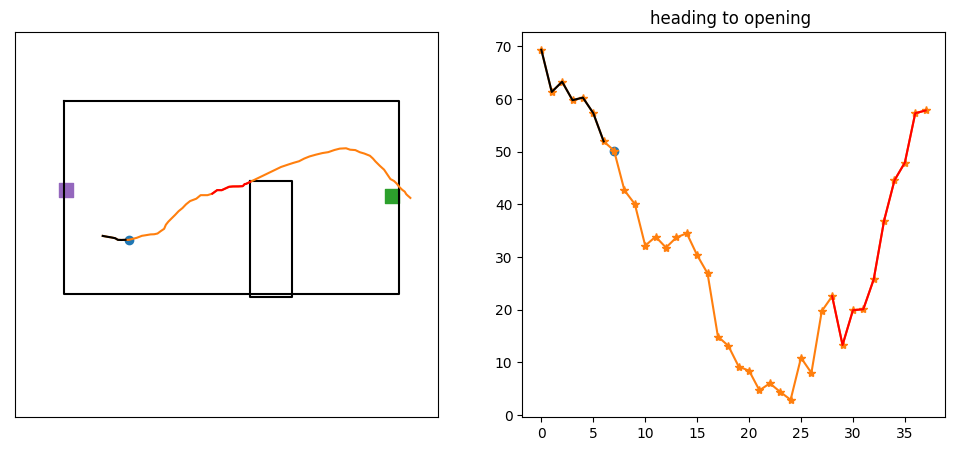

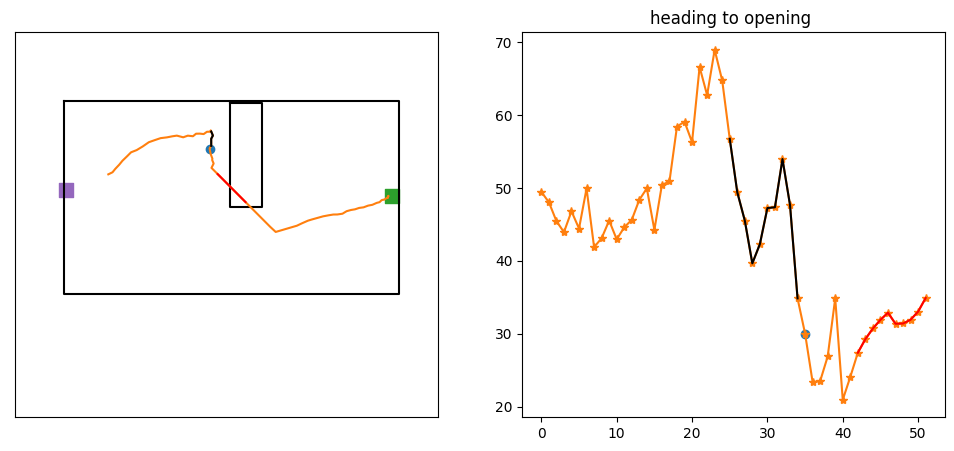

In [185]:
data =long[(long.turn_to_obstacle == 'towards') & (long.task == 'oa')].sample(20)
for ind,row in data.iterrows():
    
        
    fig,ax = plt.subplots(1,2,figsize=(12,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
  
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = data.loc[[ind]]
    plot_arena(data,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))
    turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()


    #ax[0].set_title()
   
    ax[1].set_title('heading to opening ')
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot(row.ts_nose_x_cm,row.ts_nose_y_cm,color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    #thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.ts_angle_to_corner[:int(row.obstacle_ind)],color = 'tab:orange',marker = '*')
    #ax[0].scatter(row.ts_angle_to_corner[:int(row.obstacle_ind)][])

    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][turn_index],row.ts_nose_y_cm[:int(row.obstacle_ind)][turn_index])
    ax[1].scatter(turn_index,row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index])
    length = len(row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index])
    before_x =  np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)],row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:]))[0]
    after_x =  np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)],row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:]))[0]
    
    ax[1].plot(before_x,row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:],color = 'black')
    ax[1].plot(after_x,row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:],color = 'red')
    ax[0].plot(row.ts_nose_x_cm[:int(row.obstacle_ind)][:turn_index][-10:],row.ts_nose_y_cm[:int(row.obstacle_ind)][:turn_index][-10:],color = 'black')
    ax[0].plot(row.ts_nose_x_cm[:int(row.obstacle_ind)][turn_index:][-10:],row.ts_nose_y_cm[:int(row.obstacle_ind)][turn_index:][-10:],color = 'red')

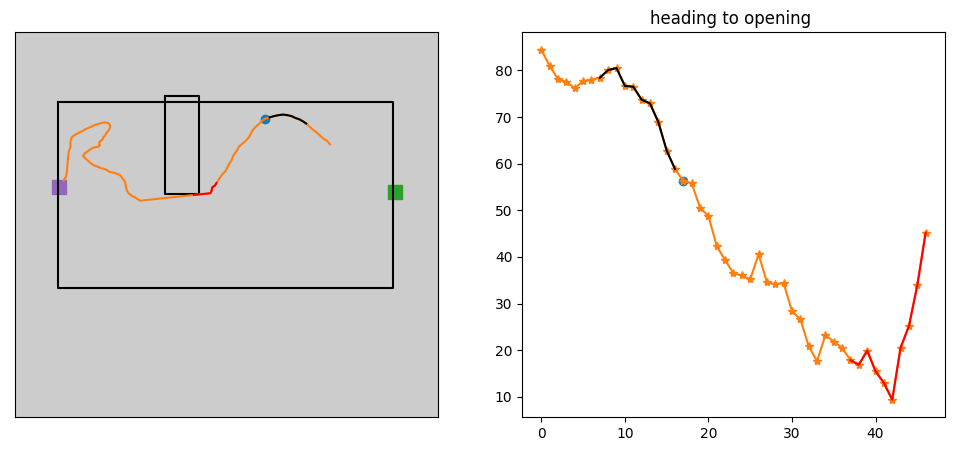

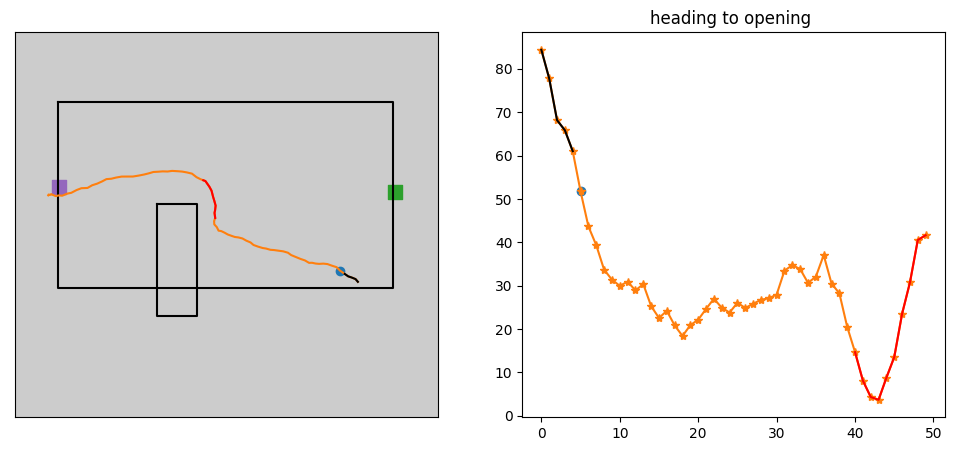

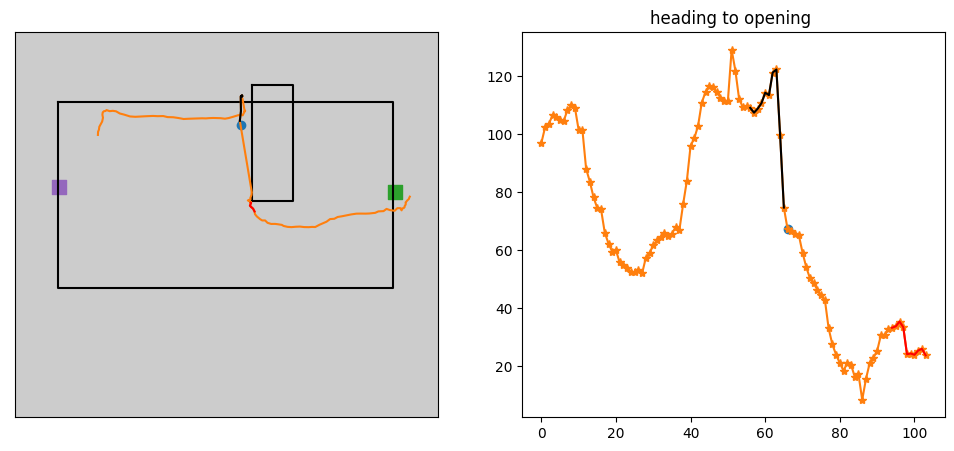

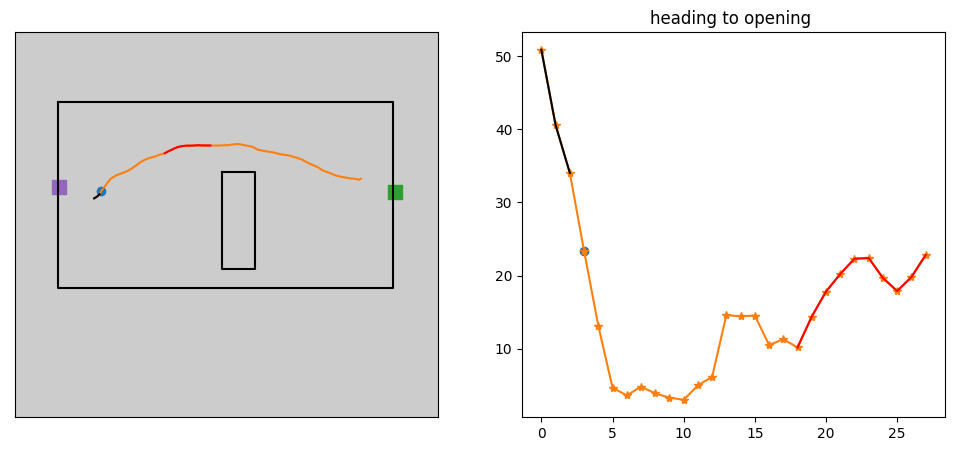

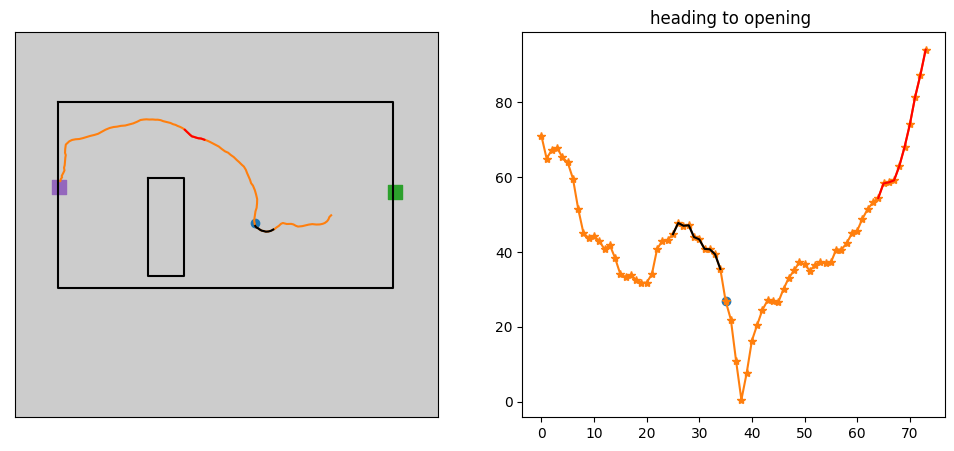

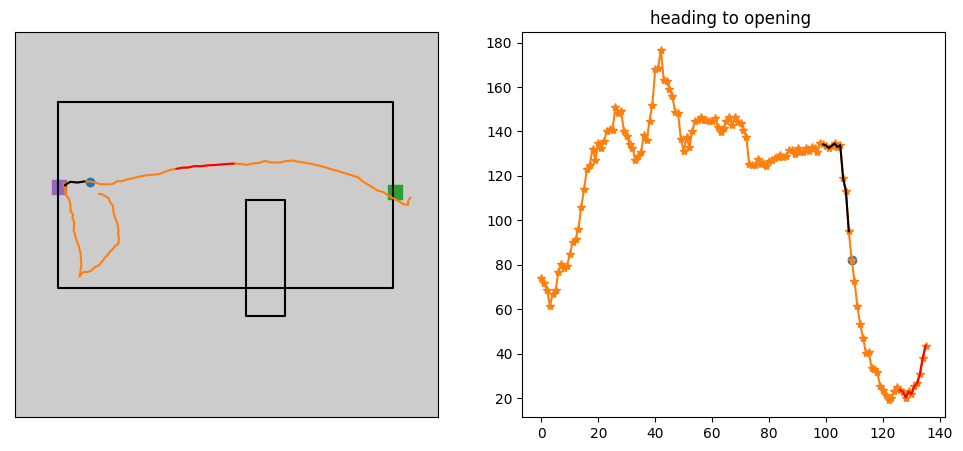

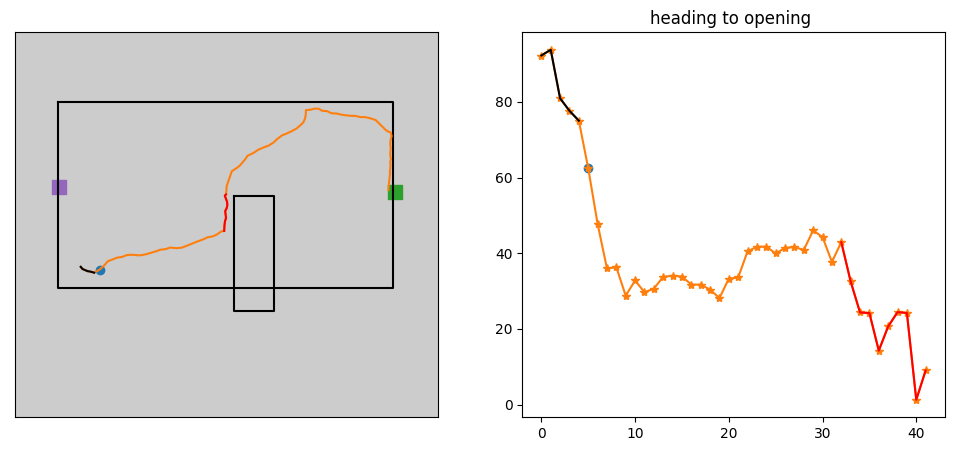

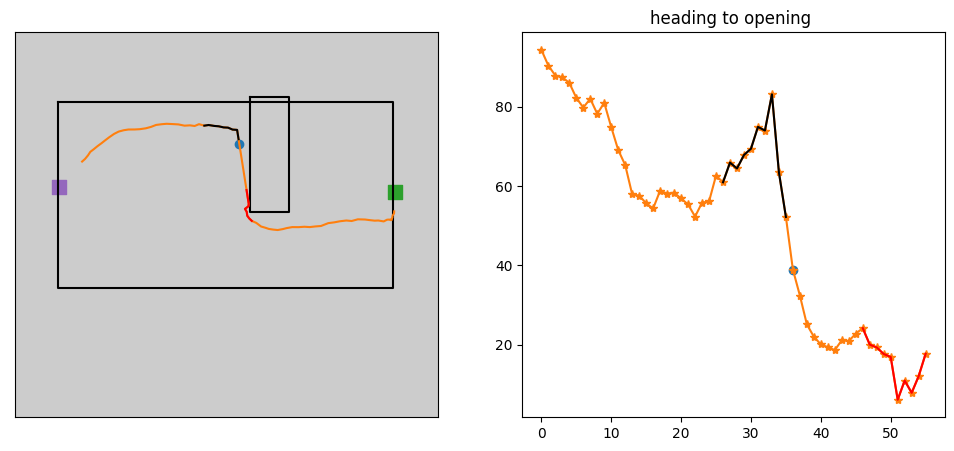

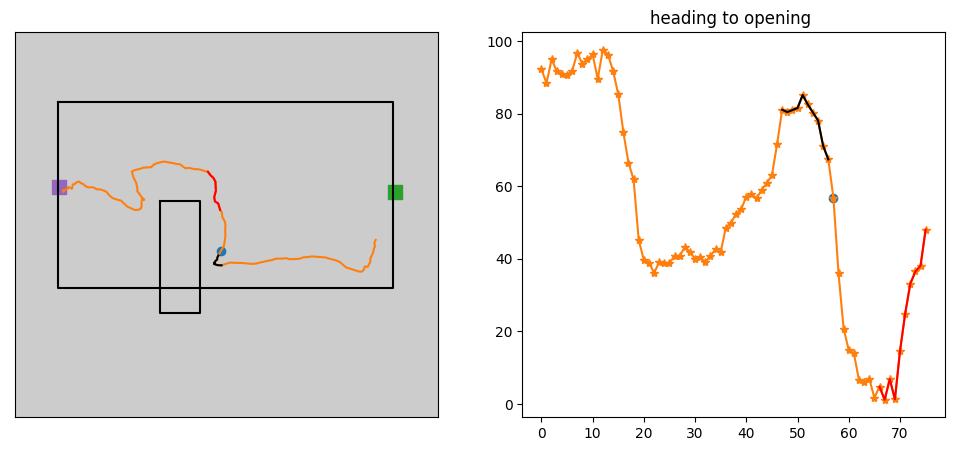

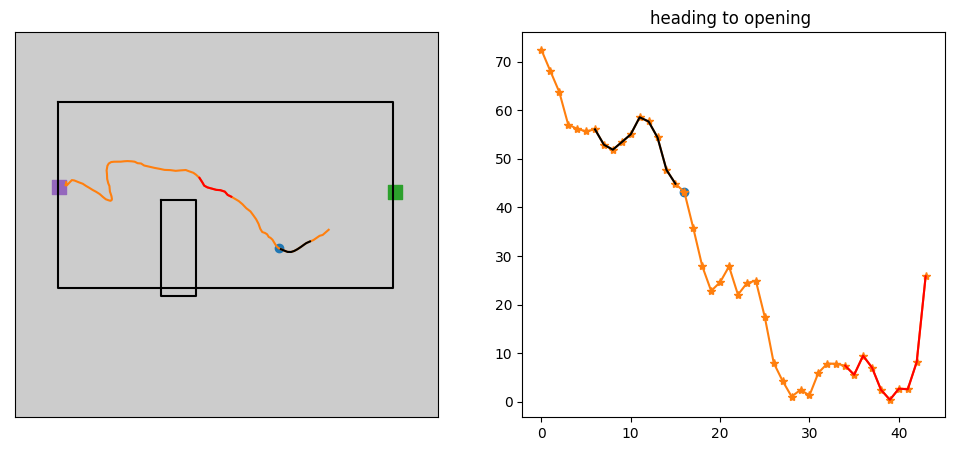

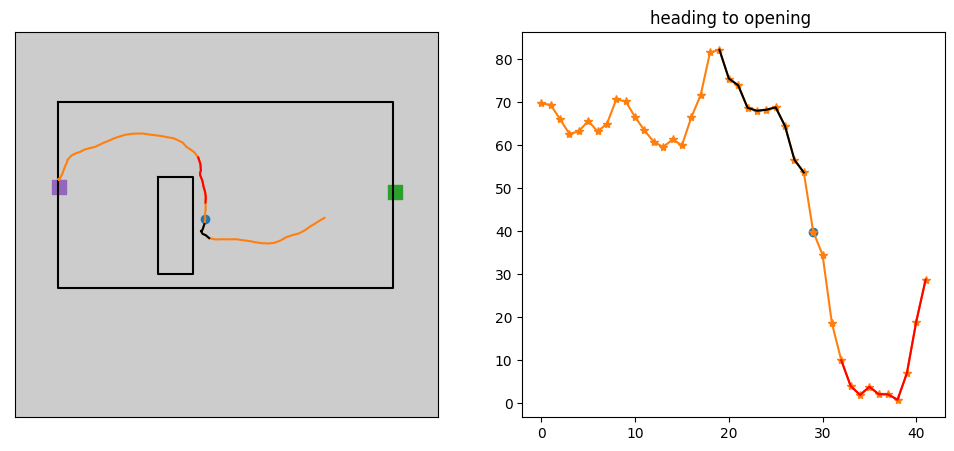

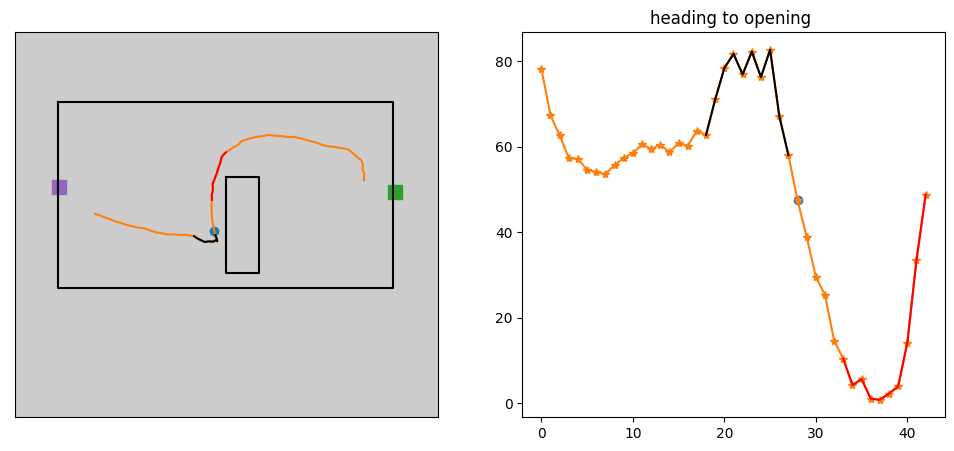

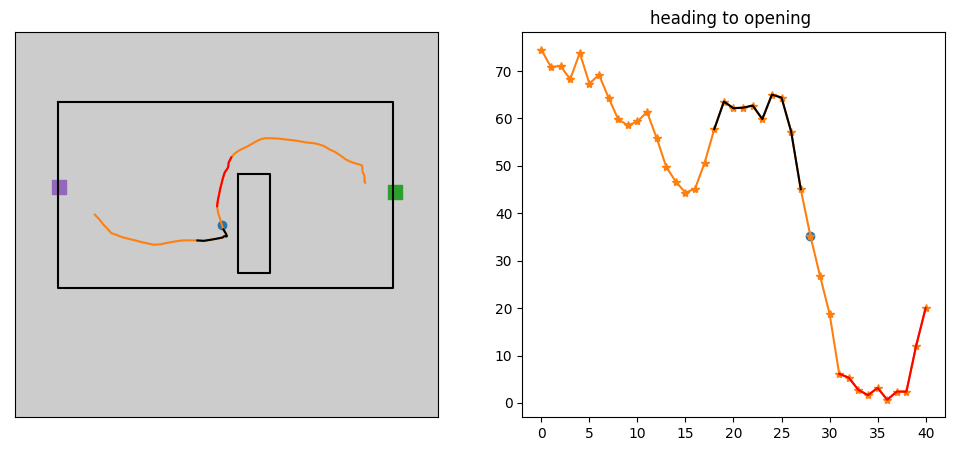

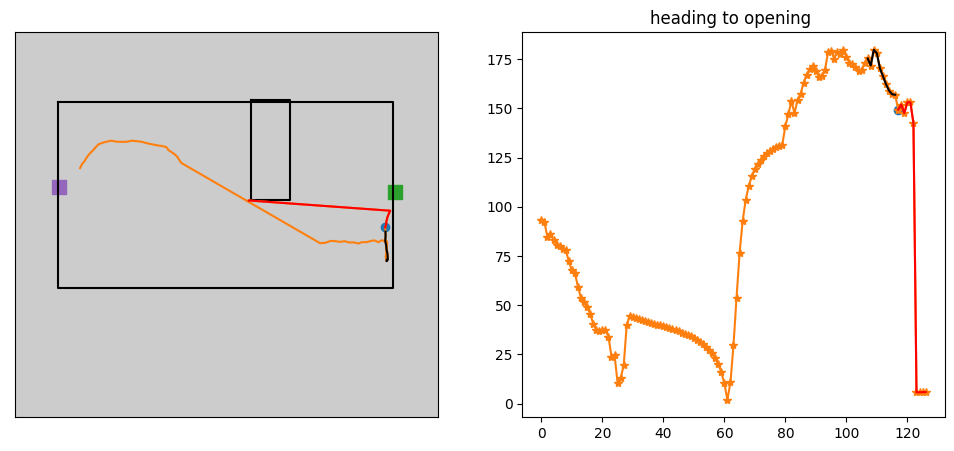

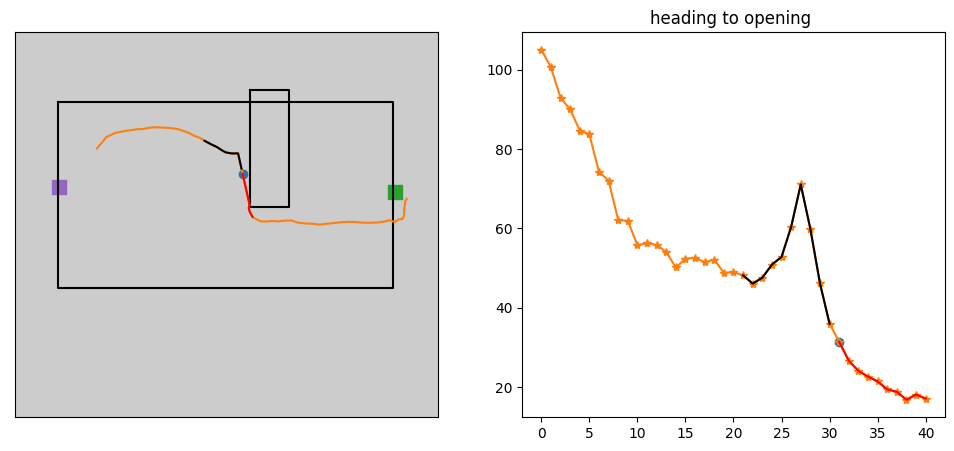

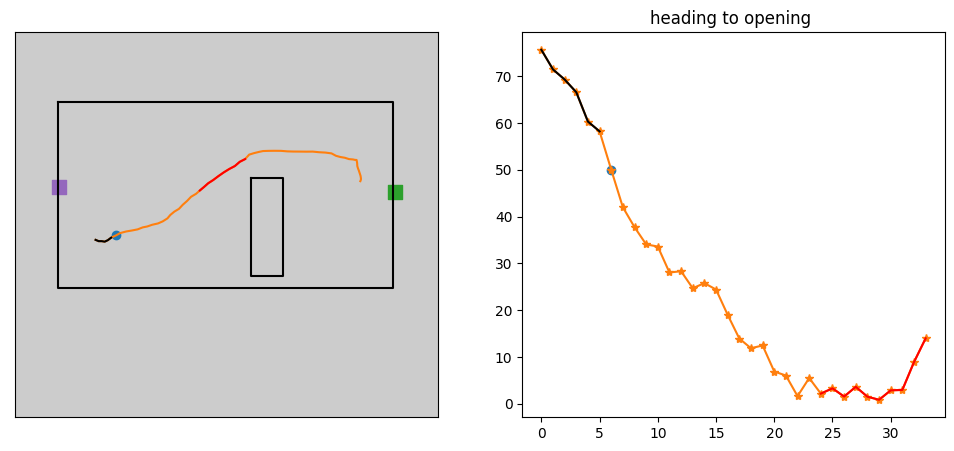

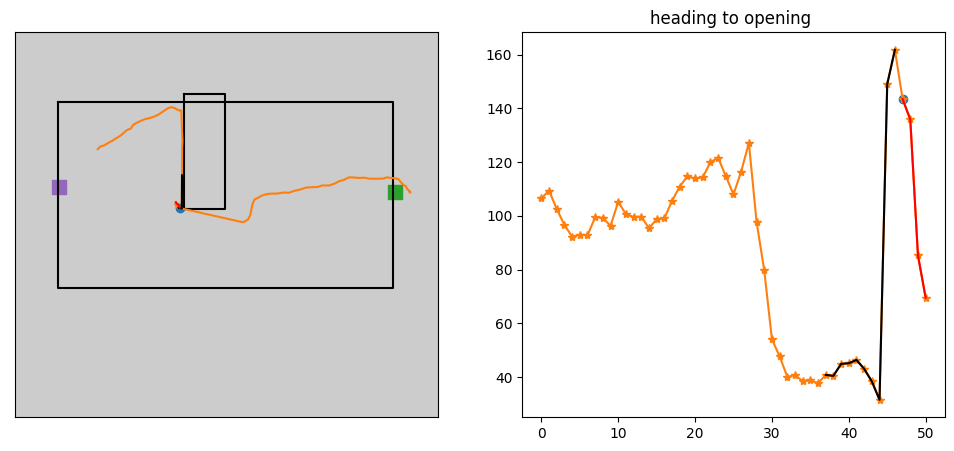

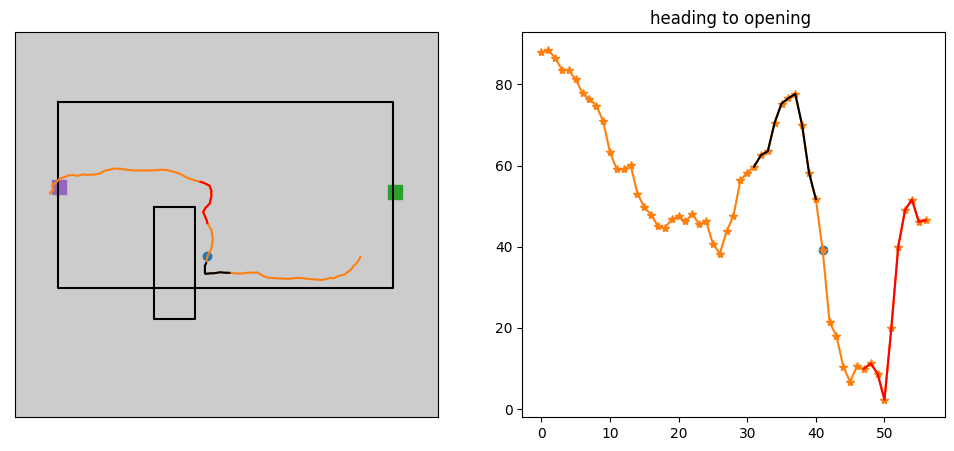

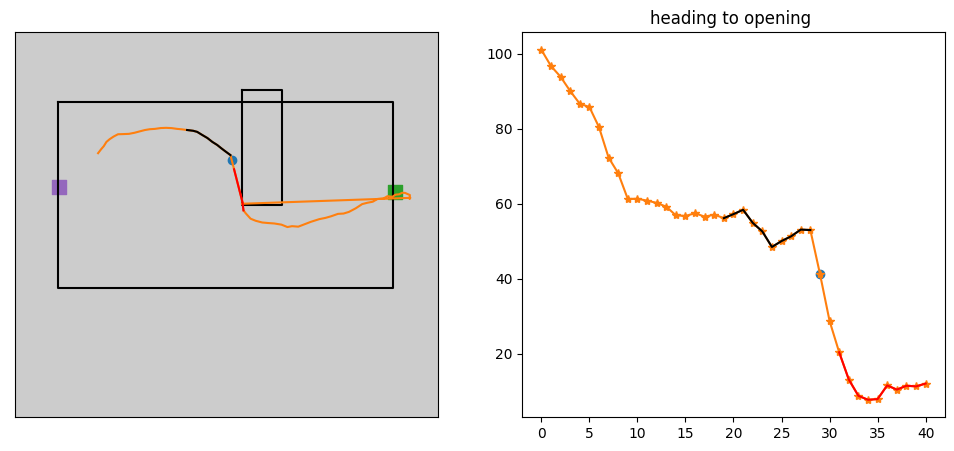

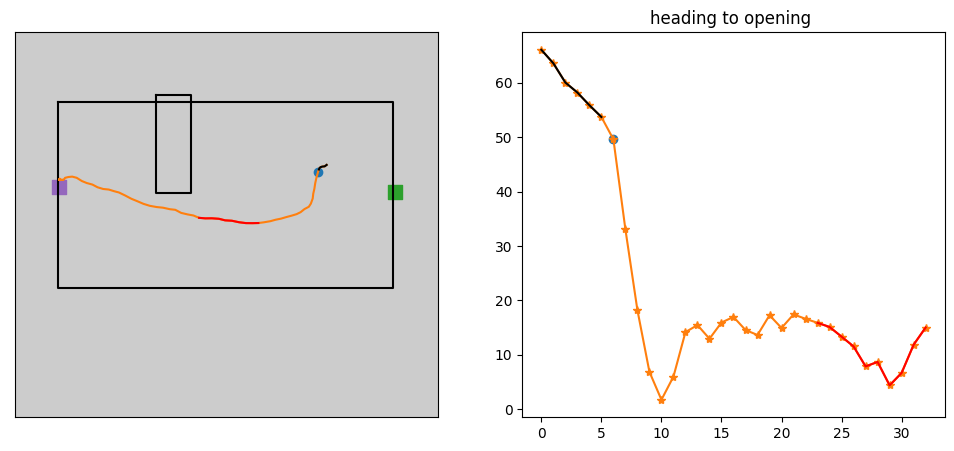

In [190]:
data =long[(long.turn_to_obstacle == 'towards') & (long.task == 'oadark')].sample(20)
for ind,row in data.iterrows():
    
        
    fig,ax = plt.subplots(1,2,figsize=(12,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
  
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = data.loc[[ind]]
    plot_arena(data,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))
    turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()


    #ax[0].set_title()
   
    ax[1].set_title('heading to opening ')
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot(row.ts_nose_x_cm,row.ts_nose_y_cm,color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    #thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.ts_angle_to_corner[:int(row.obstacle_ind)],color = 'tab:orange',marker = '*')
    #ax[0].scatter(row.ts_angle_to_corner[:int(row.obstacle_ind)][])

    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][turn_index],row.ts_nose_y_cm[:int(row.obstacle_ind)][turn_index])
    ax[1].scatter(turn_index,row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index])
    length = len(row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index])
    before_x =  np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)],row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:]))[0]
    after_x =  np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)],row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:]))[0]
    
    ax[1].plot(before_x,row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:],color = 'black')
    ax[1].plot(after_x,row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:],color = 'red')
    ax[0].plot(row.ts_nose_x_cm[:int(row.obstacle_ind)][:turn_index][-10:],row.ts_nose_y_cm[:int(row.obstacle_ind)][:turn_index][-10:],color = 'black')
    ax[0].plot(row.ts_nose_x_cm[:int(row.obstacle_ind)][turn_index:][-10:],row.ts_nose_y_cm[:int(row.obstacle_ind)][turn_index:][-10:],color = 'red')



In [104]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:]

array([61.34682949175202, 61.3484343989863, 58.07205686043562,
       53.91603248583229, 51.12597296086422, 51.065004571885964,
       50.51558191426199, 41.32460941237663, 40.20683313002137,
       37.53357443157361], dtype=object)

In [102]:
before_x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43], dtype=int64)

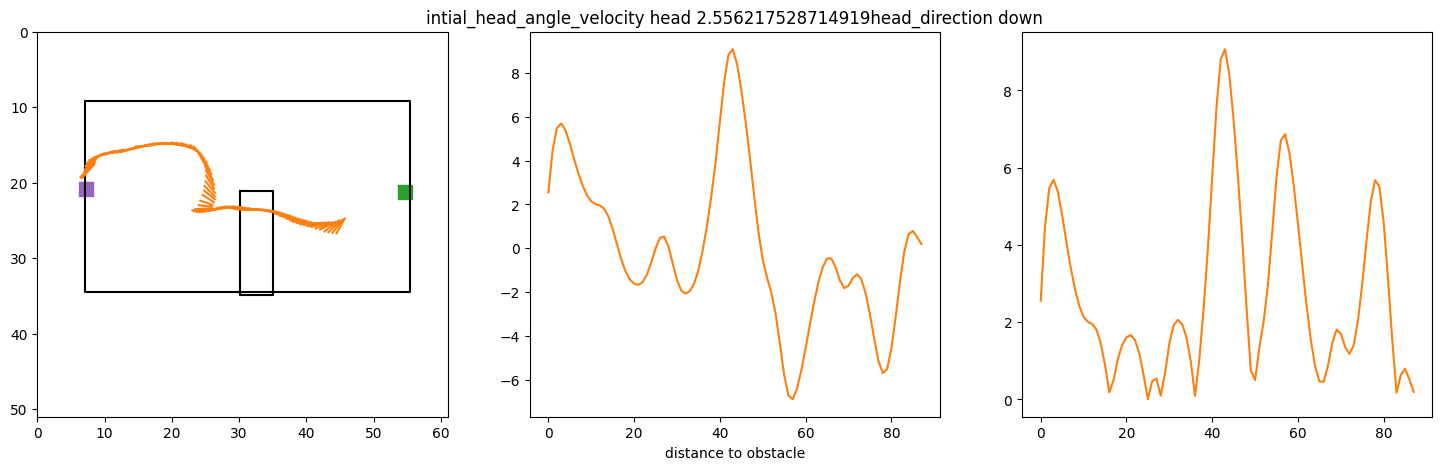

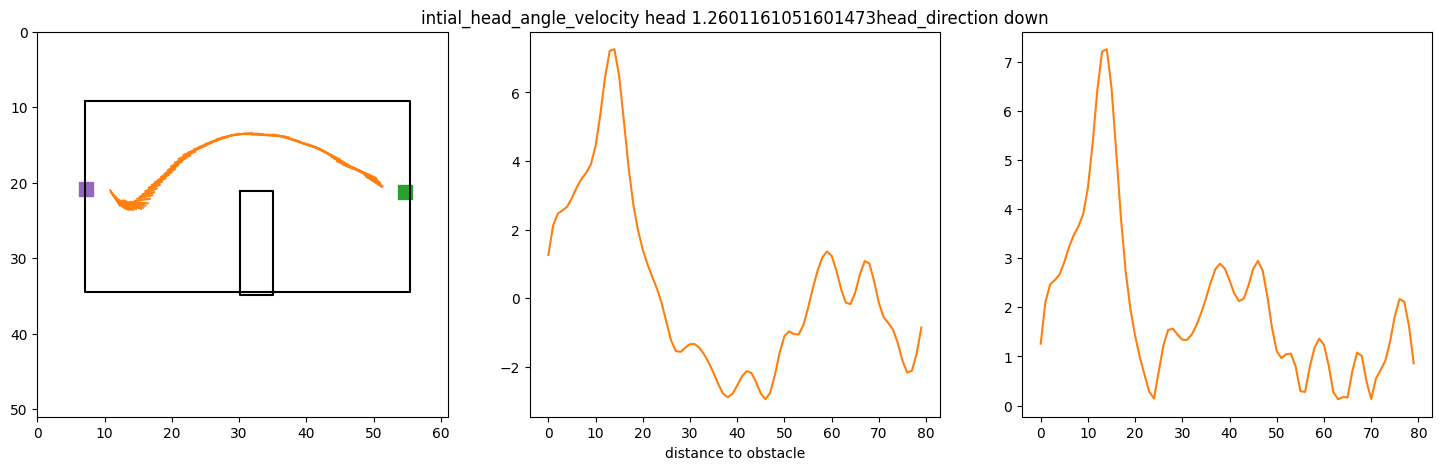

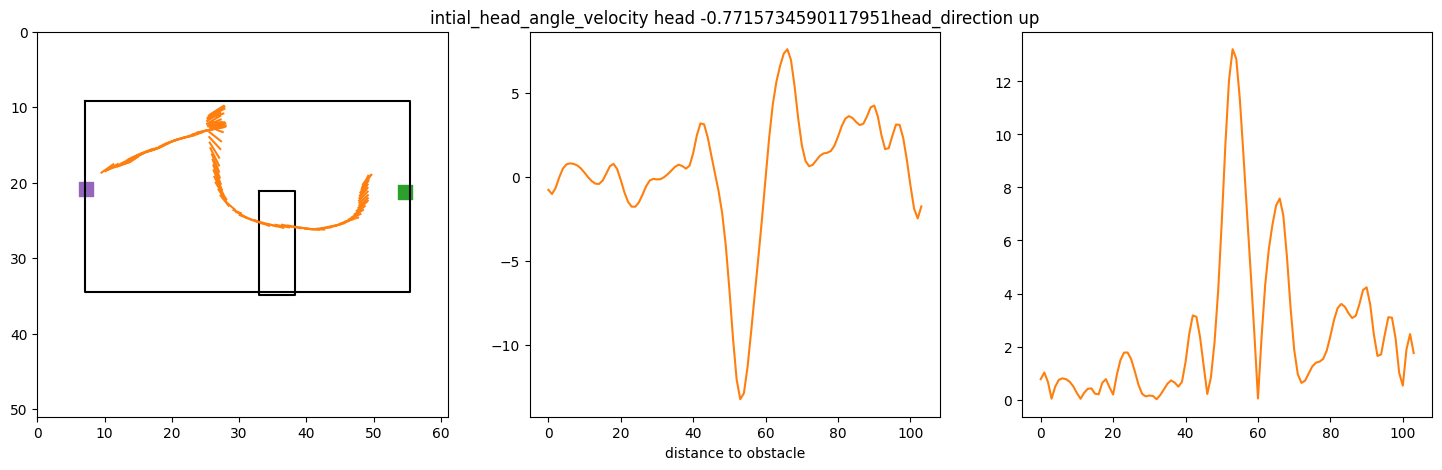

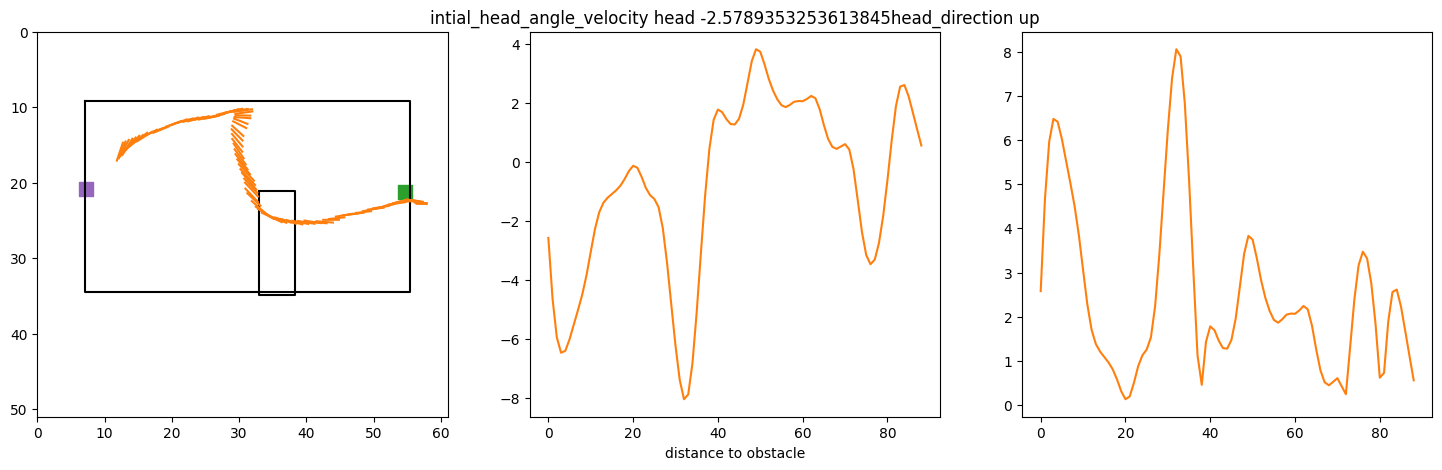

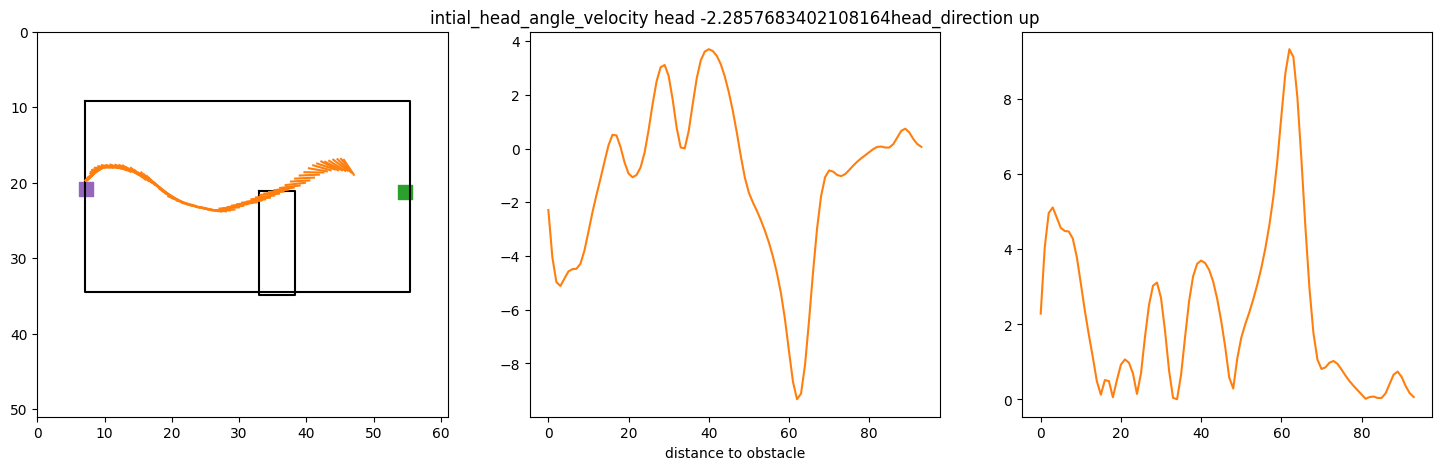

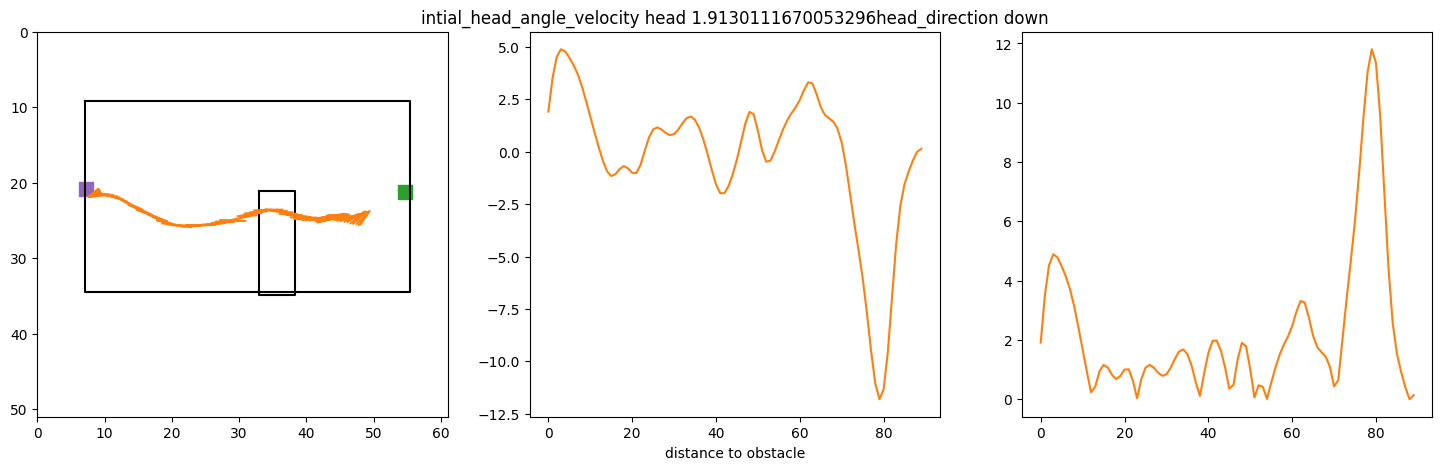

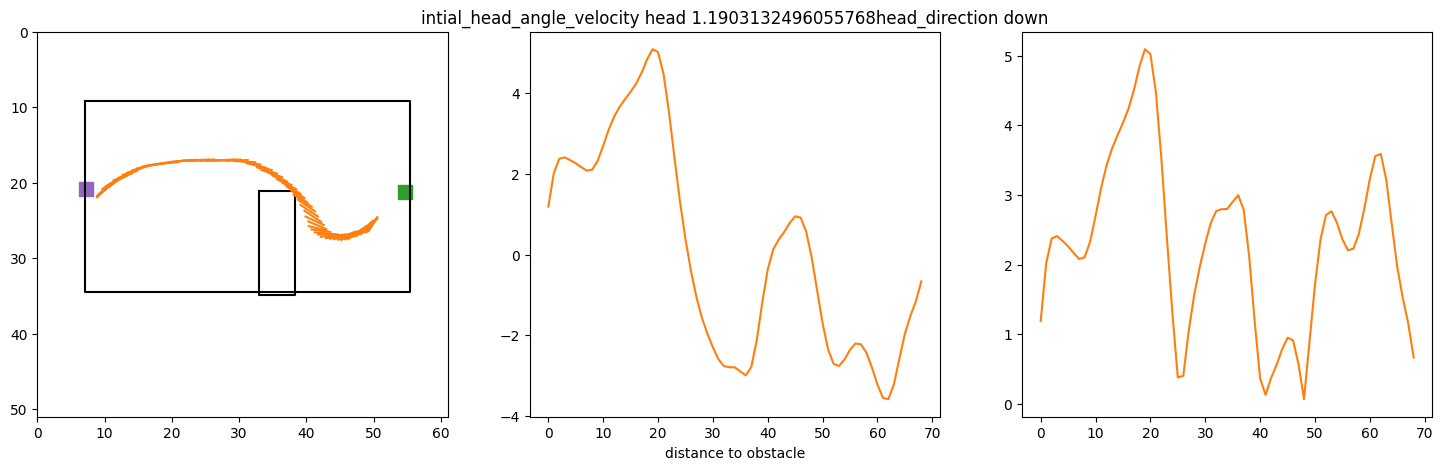

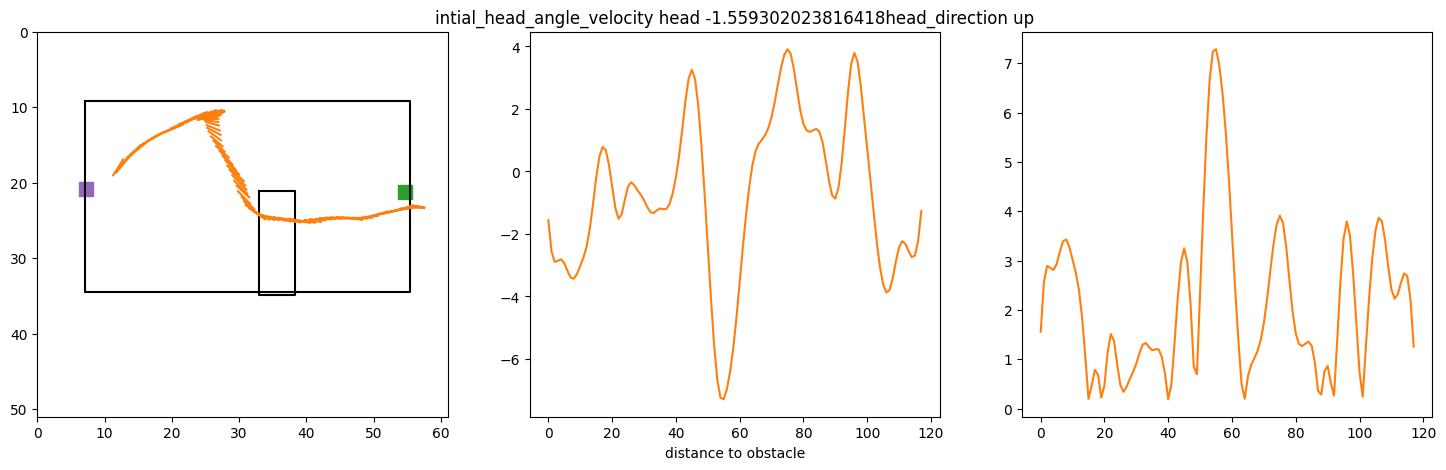

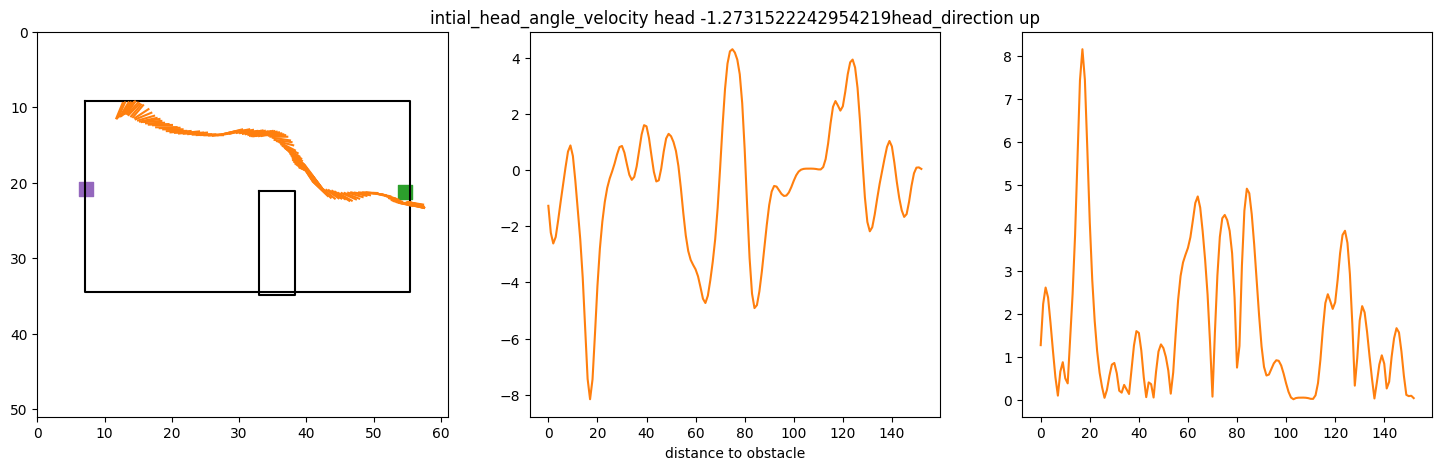

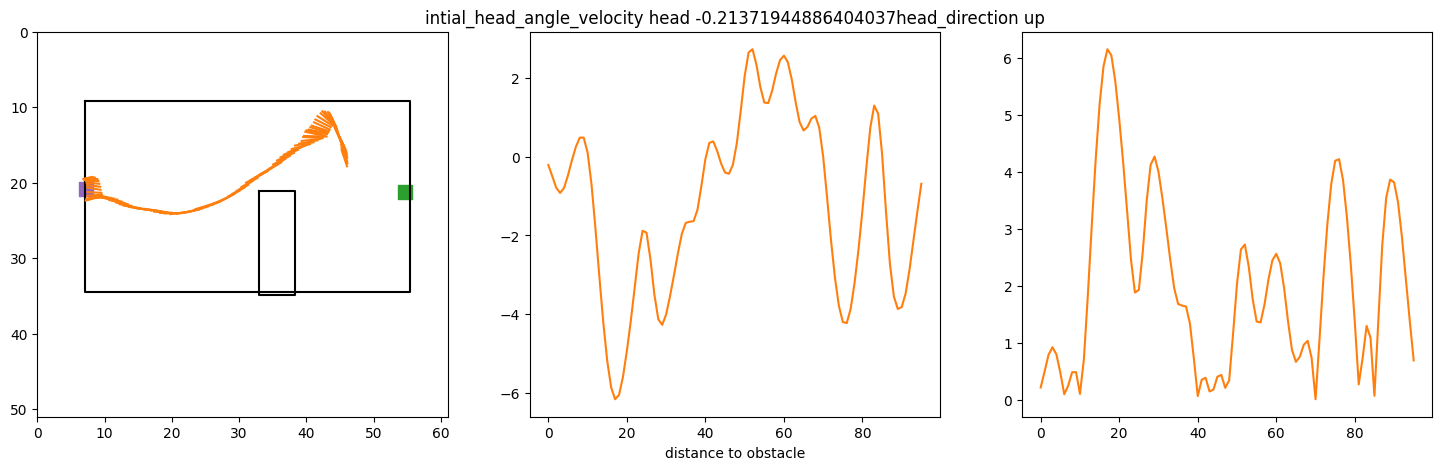

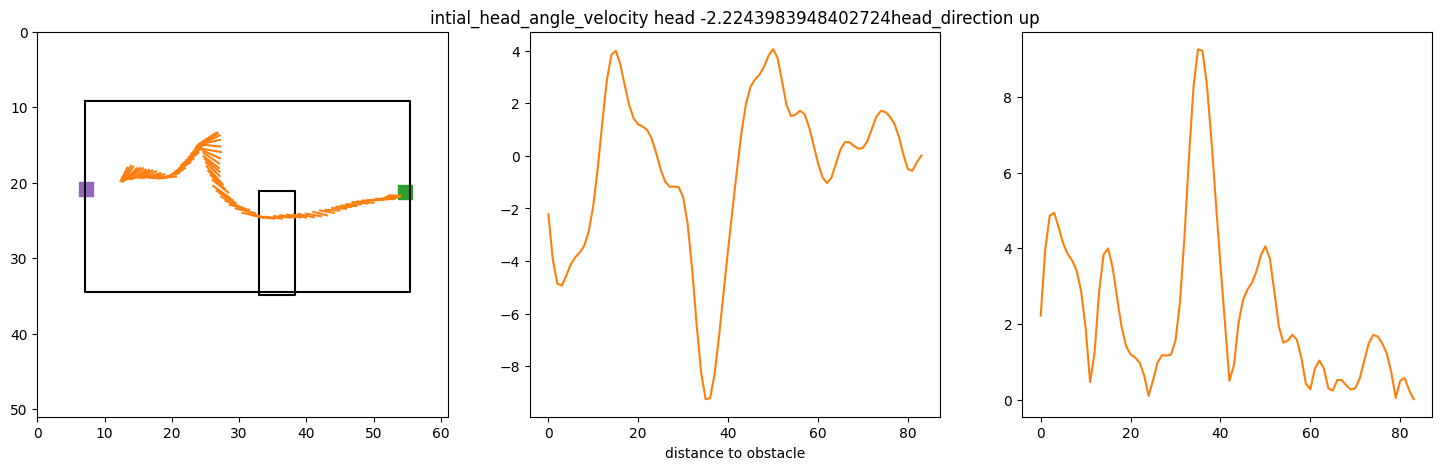

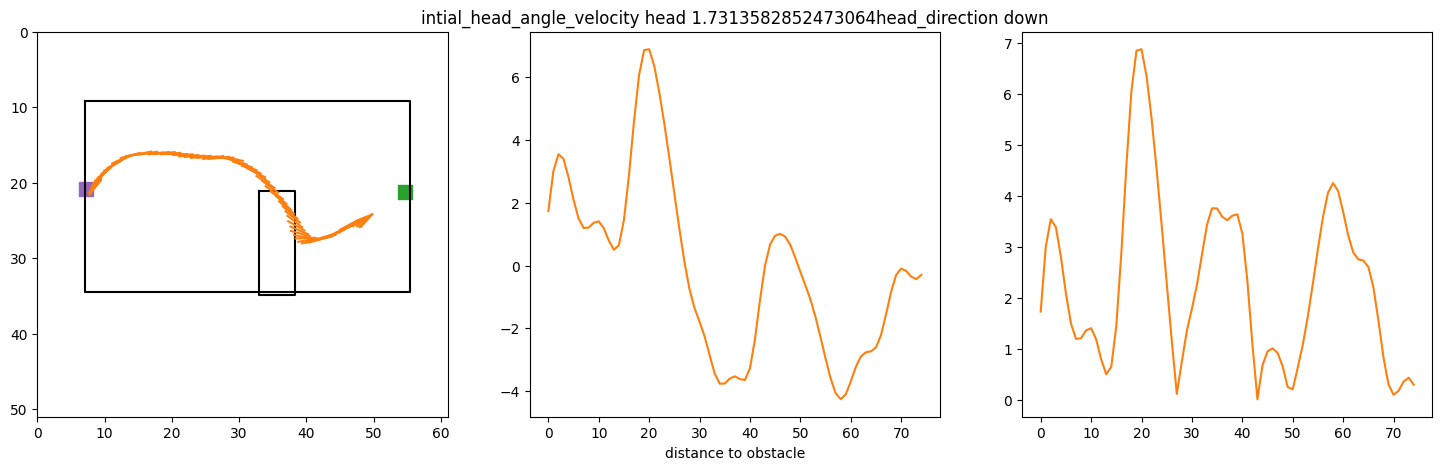

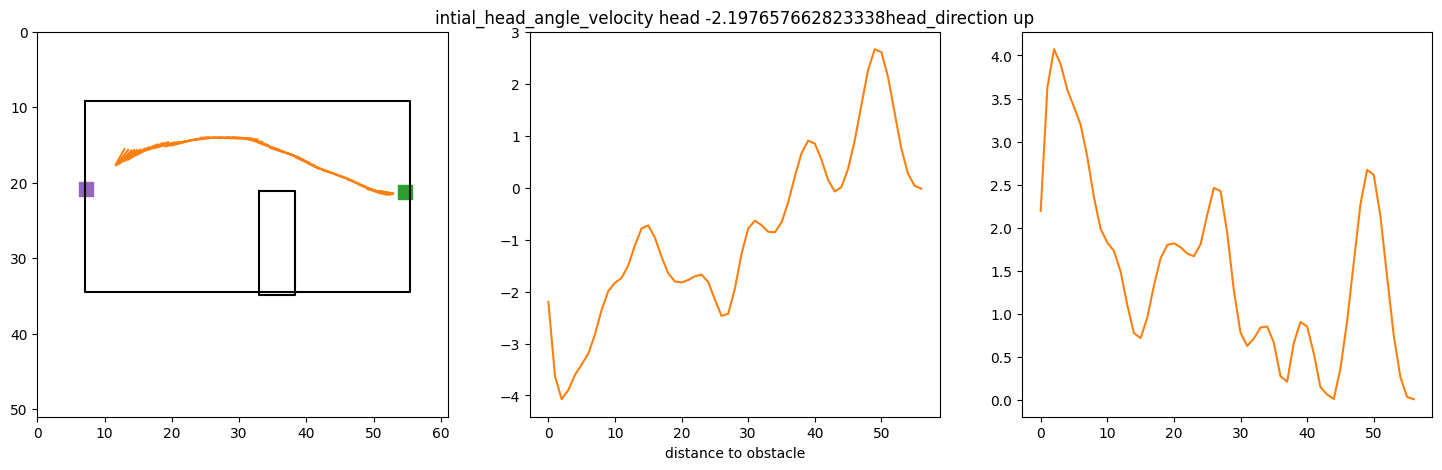

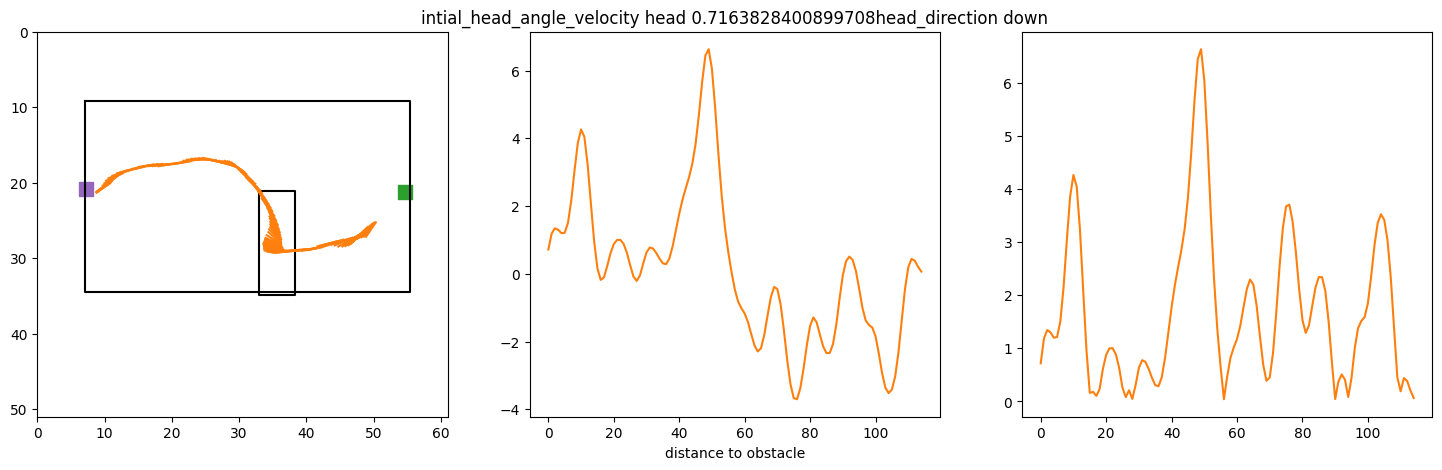

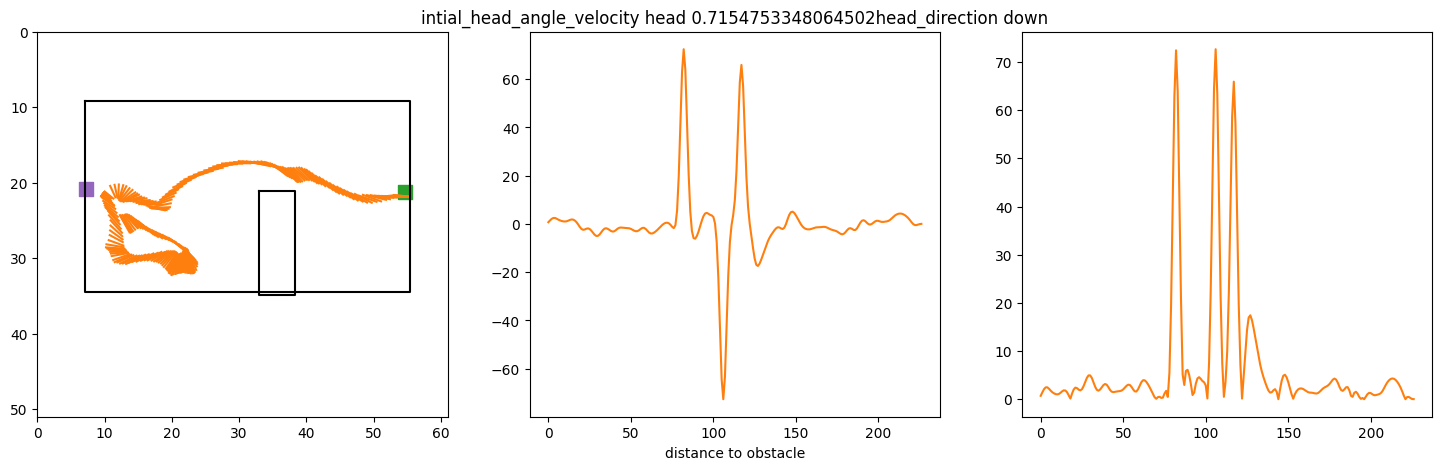

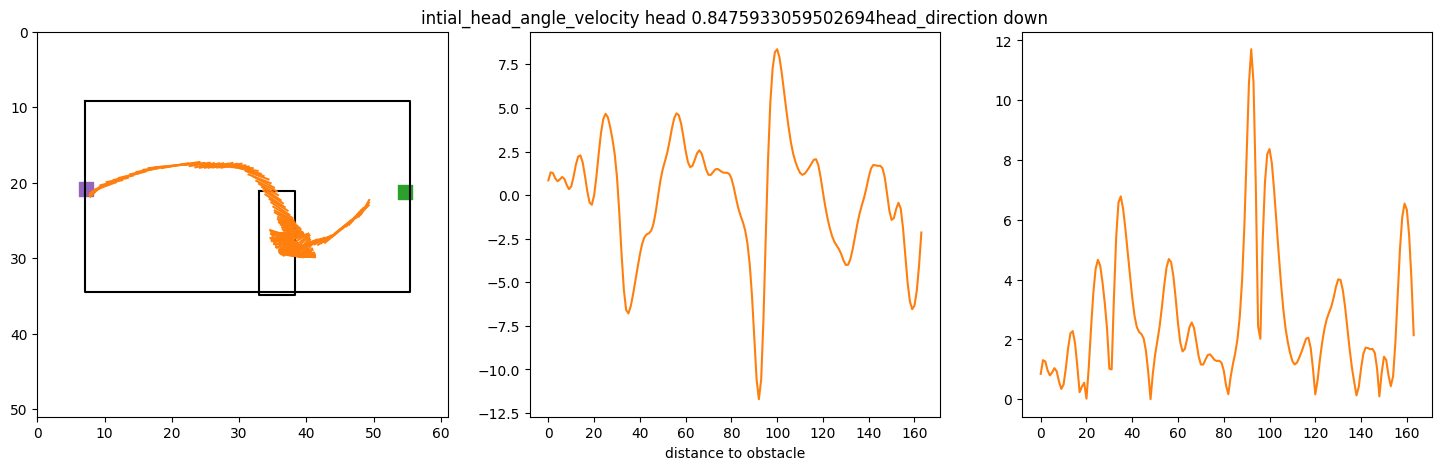

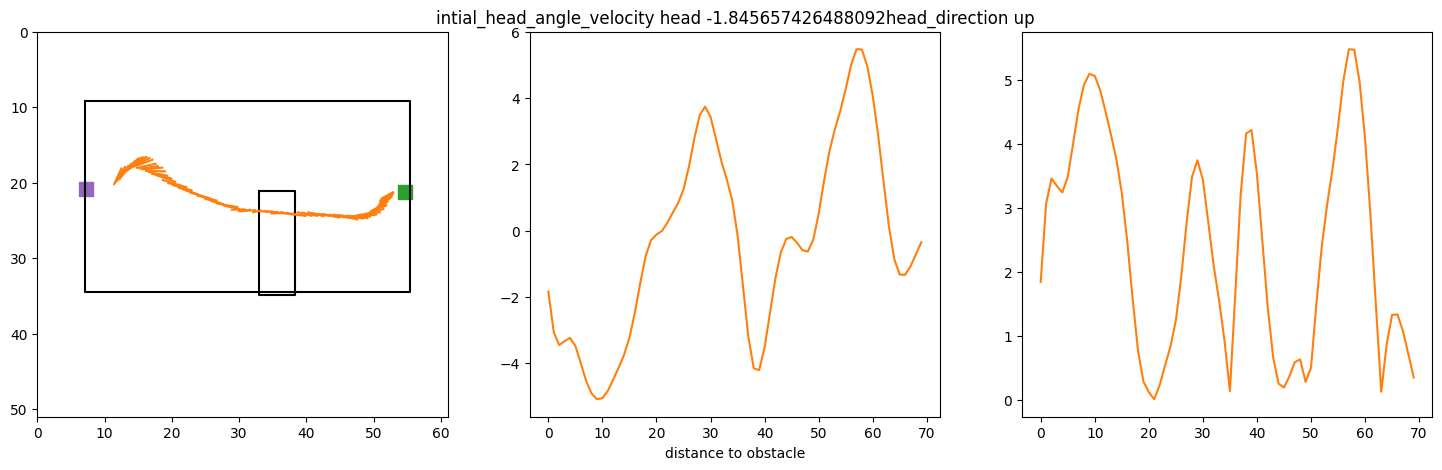

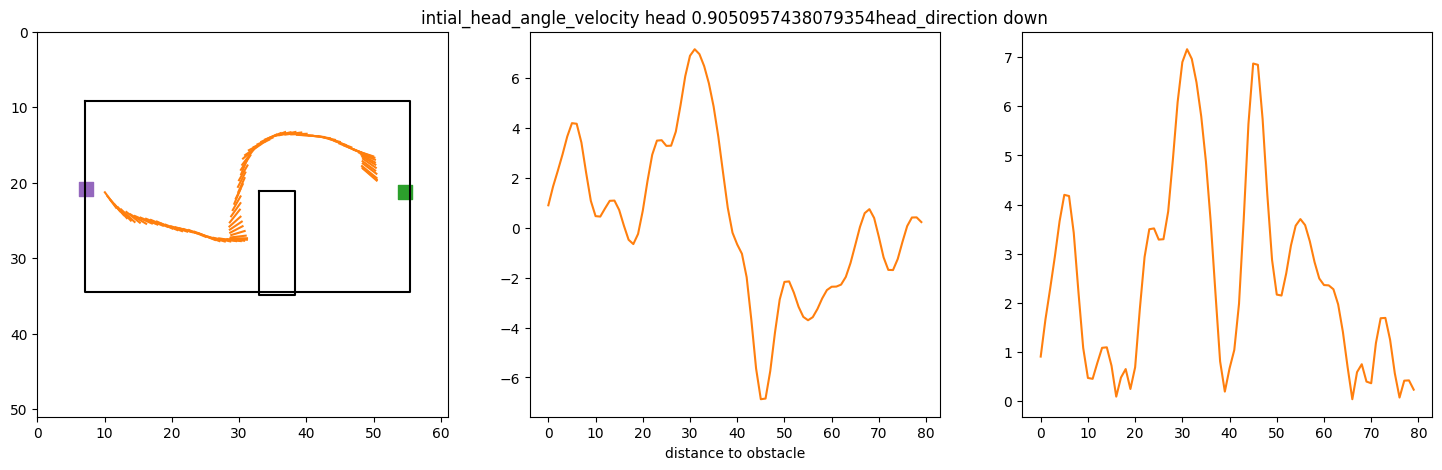

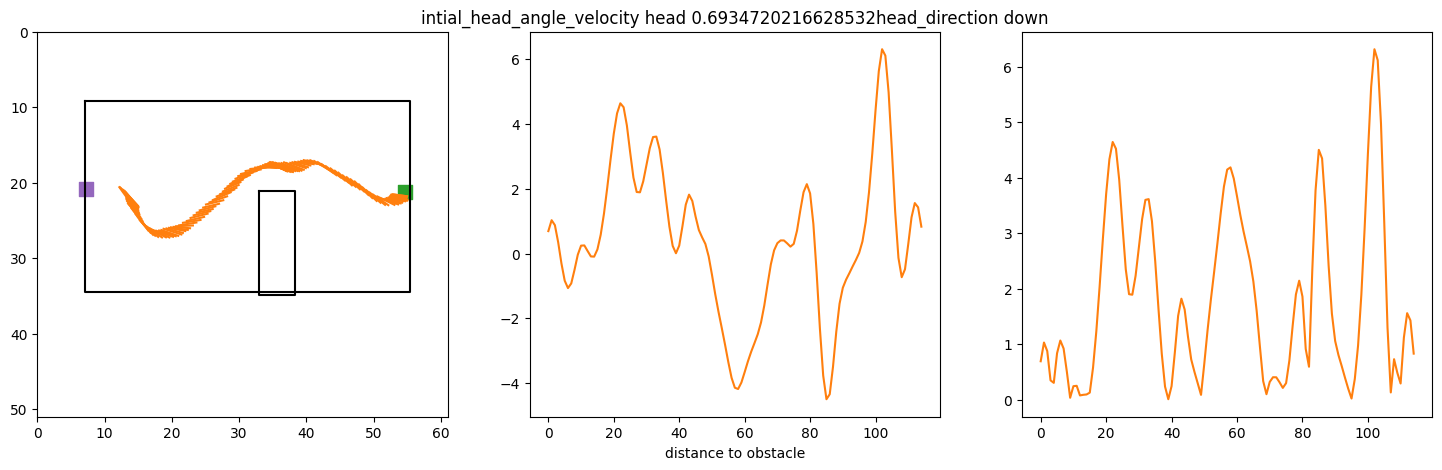

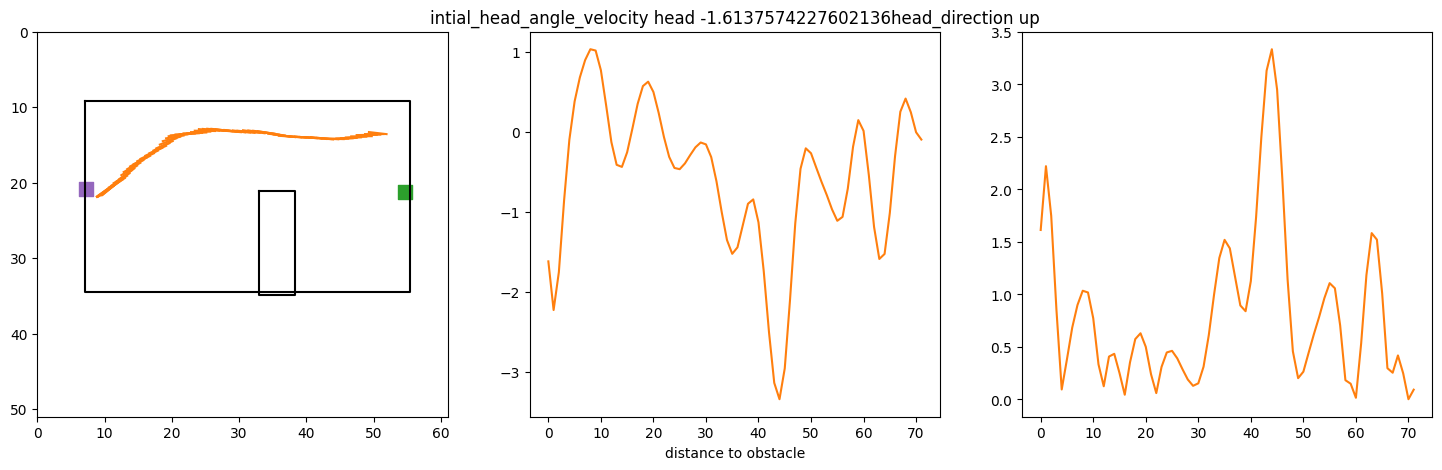

In [6]:
data =long_nostart
    
for ind,row in data.sample(20).iterrows():
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    
    #ax[1].set_xlim(20,0)
    

    if row.turn_to_obstacle == 'torwards':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))

    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        #peaks, _ = find_peaks(np.abs(row.head_angle_velocity), height=(1,10))
        ax[1].set_title('intial_head_angle_velocity head '+ str(row.intial_head_angle_velocity)+ 'head_direction ' + str(row.turn_direction))

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle')
  
        ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
        ax[1].plot(row.head_angle_velocity,color = 'tab:orange')
        ax[2].plot(np.abs(row.head_angle_velocity),color = 'tab:orange')
        #ax[2].plot(peaks, np.abs(row.head_angle_velocity)[peaks], "x")
        ax[1].scatter(peaks[0], row.head_angle_velocity[peaks[0]], marker = "x")
